# Creating the fine-tuning dataset for the MSA based on the pre-matched pre-training dataset

In [7]:
import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from astropy.table import Table
from tqdm import tqdm

pd.options.display.max_columns = None

## Grabbing APOGEE

In [8]:
data = Table.read("sdss-apogee-dr17.fits")
names = [name for name in data.colnames if len(data[name].shape) <= 1]
data = data[names].to_pandas()
print("APOGEE loaded")

APOGEE loaded


In [11]:
data.GAIAEDR3_SOURCE_ID.value_counts()

GAIAEDR3_SOURCE_ID
0                      5565
1460648219080249728      18
1460672614494496384      18
1460684709121087232      17
1460685980432727808      17
                       ... 
3145218127256410240       1
934261768926384640        1
673713350351874816        1
5273890333894734080       1
2772098031734496512       1
Name: count, Length: 651625, dtype: int64

In [12]:
# removing the duplicated sources and the sources without gaia ids because it will cause issues while finetuning
# potentially could re add them with the full trained model through a wise, 2mass, or other photometric catalogue xmatch
data = data[~data.duplicated(subset="GAIAEDR3_SOURCE_ID", keep=False)]
data.GAIAEDR3_SOURCE_ID.value_counts()

GAIAEDR3_SOURCE_ID
538028216707715712     1
1632292120300078976    1
1352085533328736384    1
4125972741086408960    1
1635662089078813952    1
                      ..
5274939749024383616    1
3137132662344118016    1
865264356267099648     1
892278704126034688     1
2772098031734496512    1
Name: count, Length: 591499, dtype: int64

In [13]:
data

,FILE,APOGEE_ID,TARGET_ID,APSTAR_ID,ASPCAP_ID,TELESCOPE,LOCATION_ID,FIELD,ALT_ID,RA,DEC,GLON,GLAT,J,J_ERR,H,H_ERR,K,K_ERR,SRC_H,WASH_M,WASH_M_ERR,WASH_T2,WASH_T2_ERR,DDO51,DDO51_ERR,IRAC_3_6,IRAC_3_6_ERR,IRAC_4_5,IRAC_4_5_ERR,IRAC_5_8,IRAC_5_8_ERR,IRAC_8_0,IRAC_8_0_ERR,WISE_4_5,WISE_4_5_ERR,TARG_4_5,TARG_4_5_ERR,WASH_DDO51_GIANT_FLAG,WASH_DDO51_STAR_FLAG,TARG_PMRA,TARG_PMDEC,TARG_PM_SRC,AK_TARG,AK_TARG_METHOD,AK_WISE,SFD_EBV,APOGEE_TARGET1,APOGEE_TARGET2,APOGEE2_TARGET1,APOGEE2_TARGET2,APOGEE2_TARGET3,APOGEE2_TARGET4,TARGFLAGS,SURVEY,PROGRAMNAME,NVISITS,SNR,SNREV,STARFLAG,STARFLAGS,ANDFLAG,ANDFLAGS,VHELIO_AVG,VSCATTER,VERR,RV_TEFF,RV_LOGG,RV_FEH,RV_ALPHA,RV_CARB,RV_CHI2,RV_CCFWHM,RV_AUTOFWHM,RV_FLAG,N_COMPONENTS,MEANFIB,SIGFIB,MIN_H,MAX_H,MIN_JK,MAX_JK,GAIAEDR3_SOURCE_ID,GAIAEDR3_PARALLAX,GAIAEDR3_PARALLAX_ERROR,GAIAEDR3_PMRA,GAIAEDR3_PMRA_ERROR,GAIAEDR3_PMDEC,GAIAEDR3_PMDEC_ERROR,GAIAEDR3_PHOT_G_MEAN_MAG,GAIAEDR3_PHOT_BP_MEAN_MAG,GAIAEDR3_PHOT_RP_MEAN_MAG,GAIAEDR3_DR2_RADIAL_VELOCITY,GAIAEDR3_DR2_RADIAL_VELOCITY_ERROR,GAIAEDR3_R_MED_GEO,GAIAEDR3_R_LO_GEO,GAIAEDR3_R_HI_GEO,GAIAEDR3_R_MED_PHOTOGEO,GAIAEDR3_R_LO_PHOTOGEO,GAIAEDR3_R_HI_PHOTOGEO,ASPCAP_GRID,ASPCAP_CHI2,ASPCAPFLAG,ASPCAPFLAGS,FRAC_BADPIX,FRAC_LOWSNR,FRAC_SIGSKY,EXTRATARG,MEMBERFLAG,MEMBER,TEFF,TEFF_ERR,LOGG,LOGG_ERR,M_H,M_H_ERR,ALPHA_M,ALPHA_M_ERR,VMICRO,VMACRO,VSINI,TEFF_SPEC,LOGG_SPEC,C_FE,C_FE_SPEC,C_FE_ERR,C_FE_FLAG,CI_FE,CI_FE_SPEC,CI_FE_ERR,CI_FE_FLAG,N_FE,N_FE_SPEC,N_FE_ERR,N_FE_FLAG,O_FE,O_FE_SPEC,O_FE_ERR,O_FE_FLAG,NA_FE,NA_FE_SPEC,NA_FE_ERR,NA_FE_FLAG,MG_FE,MG_FE_SPEC,MG_FE_ERR,MG_FE_FLAG,AL_FE,AL_FE_SPEC,AL_FE_ERR,AL_FE_FLAG,SI_FE,SI_FE_SPEC,SI_FE_ERR,SI_FE_FLAG,P_FE,P_FE_SPEC,P_FE_ERR,P_FE_FLAG,S_FE,S_FE_SPEC,S_FE_ERR,S_FE_FLAG,K_FE,K_FE_SPEC,K_FE_ERR,K_FE_FLAG,CA_FE,CA_FE_SPEC,CA_FE_ERR,CA_FE_FLAG,TI_FE,TI_FE_SPEC,TI_FE_ERR,TI_FE_FLAG,TIII_FE,TIII_FE_SPEC,TIII_FE_ERR,TIII_FE_FLAG,V_FE,V_FE_SPEC,V_FE_ERR,V_FE_FLAG,CR_FE,CR_FE_SPEC,CR_FE_ERR,CR_FE_FLAG,MN_FE,MN_FE_SPEC,MN_FE_ERR,MN_FE_FLAG,FE_H,FE_H_SPEC,FE_H_ERR,FE_H_FLAG,CO_FE,CO_FE_SPEC,CO_FE_ERR,CO_FE_FLAG,NI_FE,NI_FE_SPEC,NI_FE_ERR,NI_FE_FLAG,CU_FE,CU_FE_SPEC,CU_FE_ERR,CU_FE_FLAG,CE_FE,CE_FE_SPEC,CE_FE_ERR,CE_FE_FLAG,YB_FE,YB_FE_SPEC,YB_FE_ERR,YB_FE_FLAG
1,b'apStar-dr17-2M00000002+7417074.fits',b'2M00000002+7417074',b'apo25m.120+12.2M00000002+7417074',b'apogee.apo25m.stars.120+12.2M00000002+7417074',b'apogee.apo25m.synspec_fix.120+12.2M00000002+...,b'apo25m',5046,b'120+12',b'none',0.000103,74.285408,119.401807,11.767414,8.597,0.039,7.667,0.029,7.314,0.018,b'2MASS',NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.353,0.020,7.353,0.020,-1,1,-2.800000,2.4,b'UCAC4',0.242352,b'RJCE_WISE',0.242352,0.434002,0,0,-2147465196,0,0,0,"b'APOGEE2_TWOBIN_GT_0_8,APOGEE2_WISE_DERED,APO...",b'apogee2',b'disk',3,827.156494,669.416504,3072,"b'PERSIST_MED,PERSIST_LOW'",0,NaN,-51.731453,0.204533,0.020596,3671.801514,1.090488,-0.401404,0.0,0.0,82.418503,17.408659,12.790598,0,1,23.955153,30.171730,7.000000,12.200000,0.800000,9999.990234,538028216707715712,0.285442,0.019475,0.048582,0.024031,0.522249,0.022098,11.698800,13.272200,10.4956,-51.924702,0.365646,3234.574707,3027.029541,3464.556396,3268.601074,3115.693115,3507.732422,b'Mg_d',15.293258,0,NaN,0.000000,0.000000,0.000000,0,0,NaN,3723.911133,4.060303,0.904598,0.021523,-0.14768,0.007183,0.036922,0.004735,1.712182,3.223484,NaN,3621.699951,1.0245,0.009295,0.009295,0.008765,0,-0.006826,-0.006826,0.017671,0,0.151220,0.151220,0.010198,0,0.083402,0.026739,0.008202,0,0.050112,0.030710,0.033258,0,0.030429,-0.033094,0.010857,0,NaN,NaN,NaN,64,-0.028965,-0.023566,0.012181,0,NaN,NaN,0.086512,2,NaN,NaN,NaN,64,0.086219,0.01646,0.033020,0,-0.098512,-0.080507,0.012287,0,NaN,NaN,NaN,64,NaN,NaN,NaN,64,-0.108158,-0.153120,0.031854,0,NaN,NaN,NaN,64,NaN,NaN,NaN,64,-0.16068,-0.16068,0.009251,0,0.07509,0.02702,0.020174,0,0.007683,-0.03571,0.010609,0,NaN,NaN,0.001221,2,NaN,NaN,NaN,64,NaN,NaN,1.0,2
2,b'apStar-dr17-2M00000019-1924498.fits',b'2M00000019-1924498',b'apo25m.060-75.2M0000001

### Adding astroNN ages

In [14]:
astronn2 = pd.read_csv("nn_latent_age_dr17.csv.gz", compression="gzip")

In [15]:
astronn2 = astronn2.dropna()
astronn2 = astronn2[
    (astronn2["Age_Error"] / astronn2["Age"] < 0.4)
    & (astronn2["STARFLAG"] == 0)
    & (astronn2["ASPCAPFLAG"] == 0)
]

no STARFLAG and ASPCAPFLAG flag set as well as requiring a latent space age uncertainty less than 40% from Leung2023+

In [16]:
astronn1 = Table.read("apogee_astroNN-DR17.fits").to_pandas()

In [17]:
astronn1["APOGEE_ID"] = [val.decode("utf-8") for val in astronn1["APOGEE_ID"].values]

In [18]:
astronn2 = astronn2.drop_duplicates(subset="APOGEE_ID")
astronn1 = astronn1.drop_duplicates(subset="APOGEE_ID")

In [19]:
astronn1 = astronn1[~astronn1["APOGEE_ID"].isin(astronn2["APOGEE_ID"])]

In [20]:
astronn2

,APOGEE_ID,TELESCOPE,FIELD,STARFLAG,ASPCAPFLAG,z0,z1,z2,z3,z4,Age,Age_Error,LogAge,LogAge_Error
6,2M00000068+5710233,apo25m,N7789,0,0.0,0.109831,2.783816,0.490213,0.129695,0.558129,3.713866,1.315107,0.569826,0.138561
28,2M00000866+7122144,apo25m,120+08,0,0.0,-0.218892,-0.210707,0.335599,0.026745,-0.049675,6.893998,2.467813,0.838471,0.145866
30,2M00000943+6254542,apo25m,116+00,0,0.0,1.070844,0.019565,-0.612649,0.131504,1.010401,5.862042,1.648183,0.768049,0.134069
33,2M00001104+6348085,apo25m,117+01,0,0.0,-0.392587,2.486913,0.324700,-0.059272,0.348974,4.089180,1.374299,0.611636,0.135857
41,2M00001296+5851378,apo25m,116-04,0,0.0,-0.864830,0.355200,-0.505398,0.214336,0.278643,6.304886,2.076918,0.799677,0.164960
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
733844,2M23594733+5640020,apo25m,NGC7789_btx,0,0.0,-0.387422,1.216002,0.015684,-0.532662,0.586736,3.322011,0.391614,0.521401,0.057360
733852,2M23594841+5653269,apo25m,NGC7789_MGA,0,0.0,-0.052397,-0.401596,0.844707,0.071187,0.393542,7.658290,2.758648,0.884132,0.165442
733871,2M23595371+8506304,apo25m,NGC188_btx,0,0.0,0.069476,2.301538,-0.021433,-0.355563,0.002955,2.848126,0.609402,0.454559,0.114833
733875,2M23595481+7509560,apo25m,120+12,0,0.0,0.481890,0.615120,0.276652,0.426074,-0.893327,6.429371,2.465394,0.808168,0.182784


In [21]:
astronn = pd.concat([astronn1, astronn2])

In [22]:
astronn

,APOGEE_ID,LOCATION_ID,TELESCOPE,RA_APOGEE,DEC_APOGEE,TEFF,TEFF_ERR,LOGG,LOGG_ERR,C_H,C_H_ERR,CI_H,CI_H_ERR,N_H,N_H_ERR,O_H,O_H_ERR,NA_H,NA_H_ERR,MG_H,MG_H_ERR,AL_H,AL_H_ERR,SI_H,SI_H_ERR,P_H,P_H_ERR,S_H,S_H_ERR,K_H,K_H_ERR,CA_H,CA_H_ERR,TI_H,TI_H_ERR,TIII_H,TIII_H_ERR,V_H,V_H_ERR,CR_H,CR_H_ERR,MN_H,MN_H_ERR,FE_H,FE_H_ERR,CO_H,CO_H_ERR,NI_H,NI_H_ERR,dist,dist_error,dist_model_error,nn_parallax,nn_parallax_error,nn_parallax_model_error,fakemag,fakemag_error,weighted_dist,weighted_dist_error,RA,DEC,pmra,pmra_error,ref_epoch,pmdec,pmdec_error,phot_g_mean_mag,bp_rp,g_rp,VHELIO_AVG,age,age_linear_correct,age_lowess_correct,age_total_error,age_model_error,source_id,galr,galphi,galz,galvr,galvt,galvz,galr_err,galphi_err,galz_err,galvr_err,galvt_err,galvz_err,galvr_galvt_corr,galvr_galvz_corr,galvt_galvz_corr,e,e_err,zmax,zmax_err,rperi,rperi_err,rap,rap_err,e_zmax_corr,e_rperi_corr,e_rap_corr,zmax_rperi_corr,zmax_rap_corr,rperi_rap_corr,jr,jr_err,Lz,Lz_err,jz,jz_err,jr_Lz_corr,jr_jz_corr,lz_jz_corr,omega_r,omega_r_err,omega_phi,omega_phi_err,omega_z,omega_z_err,theta_r,theta_r_err,theta_phi,theta_phi_err,theta_z,theta_z_err,rl,rl_err,Energy,Energy_err,EminusEc,EminusEc_err,FIELD,STARFLAG,ASPCAPFLAG,z0,z1,z2,z3,z4,Age,Age_Error,LogAge,LogAge_Error
0,VESTA,1.0,b'apo1m',NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.257312,NaN,NaN,NaN,NaN,NaN,-1.000000e+00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2M00000002+7417074,5046.0,b'apo25m',0.000103,74.285408,3730.434814,49.411095,0.864455,0.091876,-0.151543,0.032733,-0.190584,0.048255,0.001321,0.031254,-0.058263,0.043236,-0.101348,0.051404,-0.100000,0.035004,-0.244900,0.063405,-0.176255,0.033154,-0.123234,0.637760,-0.105699,0.058216,-0.069167,0.068020,-0.203713,0.047183,0.080282,0.131725,-0.117781,0.090473,-0.264618,0.049702,-0.137477,0.042095,-0.052079,0.066260,-0.161563,0.036443,-0.060809,0.057862,-0.150067,0.045998,3180.051758,685.377689,327.146313,0.314460,0.067774,0.032350,8.163860,1.759508,3213.229333,172.268746,0.000205,74.285436,0.048582,0.024032,2016.0,0.522248,0.022098,11.698828,2.776685,1.203264,-51.731453,6.308862,6.842087,6.521422,3.875223,1.775135,5.380282e+17,10.045567,0.275933,0.679172,20.844429,200.097737,4.109516,0.088107,0.014094,0.034975,2.389366,0.457054,0.522038,-0.878088,0.708121,-0.630956,0.098475,0.006568,0.705461,0.041042,8.558224,0.055339,10.429574,0.194791,0.970828,0.762236,0.974737,0.892875,0.892875,0.887358,13.276805,1.911935,2018.995247,20.155264,9.611243,0.710265,0.938725,0.971362,0.991012,30.919836,0.463277,23.107880,0.344226,45.088650,1.445682,2.170873,0.072567,0.162341,0.002044,1.257675,0.029077,9.313814,0.104881,-35566.630438,541.664052,-53127.445881,237.718629,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2M00000019-1924498,5071.0,b'apo25m',0.000832,-19.413851,5517.530273,136.336548,4.045386,0.218193,-0.239434,0.041846,-0.180557,0.050743,-0.196976,0.107710,-0.058122,0.064277,-0.332414,0.315590,-0.118756,0.045523,-0.038950,0.085769,-0.129614,0.061684,0.011365,1.358047,-0.213167,0.056384,-0.171150,0.147221,-0.144306,0.065068,-0.214660,0.128373,-0.157429,0.093326,-0.228789,0.107941,-0.223622,0.121554,-0.250141,0.103008,-0.210357,0.069806,-0.576788,0.557255,-0.173068,0.067512,380.262909,53.671417,27.309965,2.629759,0.371172,0.188866,357.013306,50.389900,509.454764,42.044193,0.000970,-19.413922,20.290023,0.302588,2016.0,-10.341260,0.273871,12.288161,0.855167,0.628446,19.073862,7.416848,8.090899,7.751394,1.930535,1.426148,2.413930e+18,8.071605,0.013698,-0.471578,20.527120,208.872036,-24.368101,0.004835,0.001155,0.040

In [24]:
data["APOGEE_ID"] = [val.decode("utf-8") for val in data["APOGEE_ID"].values]

In [25]:
data = pd.merge(data, astronn, how="left", on="APOGEE_ID")

In [26]:
data.describe()

/opt/conda/lib/python3.11/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: overflow encountered in square
  sqr = _ensure_numeric((avg - values) ** 2)


,LOCATION_ID_x,RA_x,DEC_x,GLON,GLAT,J,J_ERR,H,H_ERR,K,K_ERR,WASH_M,WASH_M_ERR,WASH_T2,WASH_T2_ERR,DDO51,DDO51_ERR,IRAC_3_6,IRAC_3_6_ERR,IRAC_4_5,IRAC_4_5_ERR,IRAC_5_8,IRAC_5_8_ERR,IRAC_8_0,IRAC_8_0_ERR,WISE_4_5,WISE_4_5_ERR,TARG_4_5,TARG_4_5_ERR,WASH_DDO51_GIANT_FLAG,WASH_DDO51_STAR_FLAG,TARG_PMRA,TARG_PMDEC,AK_TARG,AK_WISE,SFD_EBV,APOGEE_TARGET1,APOGEE_TARGET2,APOGEE2_TARGET1,APOGEE2_TARGET2,APOGEE2_TARGET3,APOGEE2_TARGET4,NVISITS,SNR,SNREV,STARFLAG_x,ANDFLAG,VHELIO_AVG_x,VSCATTER,VERR,RV_TEFF,RV_LOGG,RV_FEH,RV_ALPHA,RV_CARB,RV_CHI2,RV_CCFWHM,RV_AUTOFWHM,RV_FLAG,N_COMPONENTS,MEANFIB,SIGFIB,MIN_H,MAX_H,MIN_JK,MAX_JK,GAIAEDR3_SOURCE_ID,GAIAEDR3_PARALLAX,GAIAEDR3_PARALLAX_ERROR,GAIAEDR3_PMRA,GAIAEDR3_PMRA_ERROR,GAIAEDR3_PMDEC,GAIAEDR3_PMDEC_ERROR,GAIAEDR3_PHOT_G_MEAN_MAG,GAIAEDR3_PHOT_BP_MEAN_MAG,GAIAEDR3_PHOT_RP_MEAN_MAG,GAIAEDR3_DR2_RADIAL_VELOCITY,GAIAEDR3_DR2_RADIAL_VELOCITY_ERROR,GAIAEDR3_R_MED_GEO,GAIAEDR3_R_LO_GEO,GAIAEDR3_R_HI_GEO,GAIAEDR3_R_MED_PHOTOGEO,GAIAEDR3_R_LO_PHOTOGEO,GAIAEDR3_R_HI_PHOTOGEO,ASPCAP_CHI2,ASPCAPFLAG_x,FRAC_BADPIX,FRAC_LOWSNR,FRAC_SIGSKY,EXTRATARG,MEMBERFLAG,TEFF_x,TEFF_ERR_x,LOGG_x,LOGG_ERR_x,M_H,M_H_ERR,ALPHA_M,ALPHA_M_ERR,VMICRO,VMACRO,VSINI,TEFF_SPEC,LOGG_SPEC,C_FE,C_FE_SPEC,C_FE_ERR,C_FE_FLAG,CI_FE,CI_FE_SPEC,CI_FE_ERR,CI_FE_FLAG,N_FE,N_FE_SPEC,N_FE_ERR,N_FE_FLAG,O_FE,O_FE_SPEC,O_FE_ERR,O_FE_FLAG,NA_FE,NA_FE_SPEC,NA_FE_ERR,NA_FE_FLAG,MG_FE,MG_FE_SPEC,MG_FE_ERR,MG_FE_FLAG,AL_FE,AL_FE_SPEC,AL_FE_ERR,AL_FE_FLAG,SI_FE,SI_FE_SPEC,SI_FE_ERR,SI_FE_FLAG,P_FE,P_FE_SPEC,P_FE_ERR,P_FE_FLAG,S_FE,S_FE_SPEC,S_FE_ERR,S_FE_FLAG,K_FE,K_FE_SPEC,K_FE_ERR,K_FE_FLAG,CA_FE,CA_FE_SPEC,CA_FE_ERR,CA_FE_FLAG,TI_FE,TI_FE_SPEC,TI_FE_ERR,TI_FE_FLAG,TIII_FE,TIII_FE_SPEC,TIII_FE_ERR,TIII_FE_FLAG,V_FE,V_FE_SPEC,V_FE_ERR,V_FE_FLAG,CR_FE,CR_FE_SPEC,CR_FE_ERR,CR_FE_FLAG,MN_FE,MN_FE_SPEC,MN_FE_ERR,MN_FE_FLAG,FE_H_x,FE_H_SPEC,FE_H_ERR_x,FE_H_FLAG,CO_FE,CO_FE_SPEC,CO_FE_ERR,CO_FE_FLAG,NI_FE,NI_FE_SPEC,NI_FE_ERR,NI_FE_FLAG,CU_FE,CU_FE_SPEC,CU_FE_ERR,CU_FE_FLAG,CE_FE,CE_FE_SPEC,CE_FE_ERR,CE_FE_FLAG,YB_FE,YB_FE_SPEC,YB_FE_ERR,YB_FE_FLAG,LOCATION_ID_y,RA_APOGEE,DEC_APOGEE,TEFF_y,TEFF_ERR_y,LOGG_y,LOGG_ERR_y,C_H,C_H_ERR,CI_H,CI_H_ERR,N_H,N_H_ERR,O_H,O_H_ERR,NA_H,NA_H_ERR,MG_H,MG_H_ERR,AL_H,AL_H_ERR,SI_H,SI_H_ERR,P_H,P_H_ERR,S_H,S_H_ERR,K_H,K_H_ERR,CA_H,CA_H_ERR,TI_H,TI_H_ERR,TIII_H,TIII_H_ERR,V_H,V_H_ERR,CR_H,CR_H_ERR,MN_H,MN_H_ERR,FE_H_y,FE_H_ERR_y,CO_H,CO_H_ERR,NI_H,NI_H_ERR,dist,dist_error,dist_model_error,nn_parallax,nn_parallax_error,nn_parallax_model_error,fakemag,fakemag_error,weighted_dist,weighted_dist_error,RA_y,DEC_y,pmra,pmra_error,ref_epoch,pmdec,pmdec_error,phot_g_mean_mag,bp_rp,g_rp,VHELIO_AVG_y,age,age_linear_correct,age_lowess_correct,age_total_error,age_model_error,source_id,galr,galphi,galz,galvr,galvt,galvz,galr_err,galphi_err,galz_err,galvr_err,galvt_err,galvz_err,galvr_galvt_corr,galvr_galvz_corr,galvt_galvz_corr,e,e_err,zmax,zmax_err,rperi,rperi_err,rap,rap_err,e_zmax_corr,e_rperi_corr,e_rap_corr,zmax_rperi_corr,zmax_rap_corr,rperi_rap_corr,jr,jr_err,Lz,Lz_err,jz,jz_err,jr_Lz_corr,jr_jz_corr,lz_jz_corr,omega_r,omega_r_err,omega_phi,omega_phi_err,omega_z,omega_z_err,theta_r,theta_r_err,theta_phi,theta_phi_err,theta_z,theta_z_err,rl,rl_err,Energy,Energy_err,EminusEc,EminusEc_err,STARFLAG_y,ASPCAPFLAG_y,z0,z1,z2,z3,z4,Age,Age_Error,LogAge,LogAge_Error
count,591499.000000,591499.000000,591499.000000,591499.000000,591499.000000,585319.000000,584722.000000,591496.000000,584270.000000,585312.000000,583861.000000,51983.000000,51985.000000,51985.000000,51985.000000,51985.000000,51985.000000,50993.000000,50993.000000,51604.000000,51604.000000,38239.000000,38239.000000,37915.000000,37915.000000,565786.000000,565752.000000,324304.000000,324294.000000,591499.000000,591499.000000,591499.000000,591499.000000,562155.000000,564699.000000,468682.000000,5.914990e+05,5.914990e+05,5.914990e+05,5.914990e+05,5.914990e+05,591499.0,591499.000000,591499.000000,591499.000000,5.914990e+05,5.914990e+05,583682.000000,591499.000000,591499.00000

In [27]:
data.GAIAEDR3_SOURCE_ID.dtypes

dtype('int64')

In [35]:
data[~np.isnan(data["Age"])].dropna(subset="bp_1")

,source_id,teff,e_teff,logg,e_logg,fe_h,e_fe_h,alpha,e_alpha,age,e_age,W1,W2,G,BP,RP,bp_1,bp_2,bp_3,bp_4,bp_5,bp_6,bp_7,bp_8,bp_9,bp_10,bp_11,bp_12,bp_13,bp_14,bp_15,bp_16,bp_17,bp_18,bp_19,bp_20,bp_21,bp_22,bp_23,bp_24,bp_25,bp_26,bp_27,bp_28,bp_29,bp_30,bp_31,bp_32,bp_33,bp_34,bp_35,bp_36,bp_37,bp_38,bp_39,bp_40,bp_41,bp_42,bp_43,bp_44,bp_45,bp_46,bp_47,bp_48,bp_49,bp_50,bp_51,bp_52,bp_53,bp_54,bp_55,rp_1,rp_2,rp_3,rp_4,rp_5,rp_6,rp_7,rp_8,rp_9,rp_10,rp_11,rp_12,rp_13,rp_14,rp_15,rp_16,rp_17,rp_18,rp_19,rp_20,rp_21,rp_22,rp_23,rp_24,rp_25,rp_26,rp_27,rp_28,rp_29,rp_30,rp_31,rp_32,rp_33,rp_34,rp_35,rp_36,rp_37,rp_38,rp_39,rp_40,rp_41,rp_42,rp_43,rp_44,rp_45,rp_46,rp_47,rp_48,rp_49,rp_50,rp_51,rp_52,rp_53,rp_54,rp_55,bpe_1,bpe_2,bpe_3,bpe_4,bpe_5,bpe_6,bpe_7,bpe_8,bpe_9,bpe_10,bpe_11,bpe_12,bpe_13,bpe_14,bpe_15,bpe_16,bpe_17,bpe_18,bpe_19,bpe_20,bpe_21,bpe_22,bpe_23,bpe_24,bpe_25,bpe_26,bpe_27,bpe_28,bpe_29,bpe_30,bpe_31,bpe_32,bpe_33,bpe_34,bpe_35,bpe_36,bpe_37,bpe_38,bpe_39,bpe_40,bpe_41,bpe_42,bpe_43,bpe_44,bpe_45,bpe_46,bpe_47,bpe_48,bpe_49,bpe_50,bpe_51,bpe_52,bpe_53,bpe_54,bpe_55,rpe_1,rpe_2,rpe_3,rpe_4,rpe_5,rpe_6,rpe_7,rpe_8,rpe_9,rpe_10,rpe_11,rpe_12,rpe_13,rpe_14,rpe_15,rpe_16,rpe_17,rpe_18,rpe_19,rpe_20,rpe_21,rpe_22,rpe_23,rpe_24,rpe_25,rpe_26,rpe_27,rpe_28,rpe_29,rpe_30,rpe_31,rpe_32,rpe_33,rpe_34,rpe_35,rpe_36,rpe_37,rpe_38,rpe_39,rpe_40,rpe_41,rpe_42,rpe_43,rpe_44,rpe_45,rpe_46,rpe_47,rpe_48,rpe_49,rpe_50,rpe_51,rpe_52,rpe_53,rpe_54,rpe_55,U_SMSS,RA,DEC,E_U_SMSS,V_SMSS,E_V_SMSS,G_SMSS,E_G_SMSS,R_SMSS,E_R_SMSS,I_SMSS,E_I_SMSS,Z_SMSS,E_Z_SMSS,U_SDSS,E_U_SDSS,G_SDSS,E_G_SDSS,R_SDSS,E_R_SDSS,I_SDSS,E_I_SDSS,Z_SDSS,E_Z_SDSS,G_PS1,E_G_PS1,R_PS1,E_R_PS1,I_PS1,E_I_PS1,Z_PS1,E_Z_PS1,Y_PS1,E_Y_PS1,J,E_J,H,E_H,KS,E_KS,PARALLAX,EBV,ruwe,pmra,pmdec,e_pmra,e_pmdec,pmradec_corr,g_flux_error,bp_flux_error,rp_flux_error,e_parallax
3,421077597267551104,5031.263672,10.145057,3.456132,0.023554,-0.160080,0.006013,0.055704,0.006063,3.713866,1.315107,9.992,10.042,12.275905,12.831100,11.569275,440427.750879,-12879.553124,-15665.474147,3100.726500,-3076.004889,1008.572770,-2345.479039,-411.838574,-87.308848,137.577274,14.767591,57.491103,-399.499085,-99.156845,-147.311360,-493.036169,93.230650,-34.471774,-398.515275,23.038647,46.856580,285.974972,-130.165367,151.950321,-213.929795,-58.204711,146.442083,-167.046491,82.201683,-63.613075,1.623623,53.429125,-10.464388,77.963569,-19.522850,-79.349404,-11.128331,-88.384223,48.289542,22.163590,-35.194446,61.473102,117.535576,23.549580,24.949998,-26.289915,-10.181555,-42.268802,-8.736112,-30.305266,-4.436873,-0.476461,6.353368,-2.731914,-2.669897,586254.545433,-43541.010419,1698.948093,3531.699641,915.340768,-2116.349941,-1120.774251,376.257771,-470.158140,82.300855,295.642202,182.842294,410.494057,76.964639,-55.681949,-121.794726,-85.622892,8.006261,-81.770506,47.531480,-59.701120,164.324509,21.861116,29.929562,87.785196,183.783606,-57.693040,128.662060,2.081340,12.167822,85.454470,61.604695,-35.983742,70.515128,38.752935,-49.172833,16.815587,-11.905011,18.211407,49.561969,-11.298374,11.149206,27.442355,58.000536,-33.062678,13.157942,-29.420540,28.648395,-54.138076,-27.795899,19.545102,14.088704,0.431535,2.851006,10.293322,6.693984,5.800074,6.008197,5.887903,6.105895,4.930681,4.660395,6.942408,4.166617,5.404191,5.474430,5.055091,5.220256,3.750518,3.851120,4.852163,4.533717,3.843572,4.206349,2.723246,4.752637,3.300753,4.100982,3.620572,3.827815,3.511766,2.818531,1.829810,2.855146,2.037195,2.260569,2.089649,1.671304,2.073995,1.613242,1.800638,1.682174,1.598188,1.610616,1.722298,1.378599,1.700260,1.977581,1.192512,1.402278,1.872619,1.680484,1.205750,1.200226,0.906141,0.921434,0.419400,0.640159,0.274738,0.120147,3.442444,3.230968,3.167349,3.518581,3.279060,3.408196,3.348308,3.181311,3.082938,3.389935,2.848721,3.291789,2.278432,3.229314,3.147356,3.357000,3.228041,2.924986,2.871999,3.269404,2.484425,3.147709,2.817643,2.793455,3.074869,2.966699,2.969163,2.703411,2.457936,2.361225,2.484395,2.036121,2.

Having that low data is frustrating

In [23]:
cols_to_keep = [
    "GAIAEDR3_SOURCE_ID",
    "TEFF_x",
    "TEFF_ERR_x",
    "LOGG_x",
    "LOGG_ERR_x",
    "M_H",
    "M_H_ERR",
    "ALPHA_M",
    "ALPHA_M_ERR",
    "Age",
    "Age_Error",
    "age",
    "age_total_error",
]
renamed_cols = [
    "gaiadr3_source_id",
    "teff",
    "e_teff",
    "logg",
    "e_logg",
    "fe_h",
    "e_fe_h",
    "alpha",
    "e_alpha",
    "age",
    "e_age",
]

In [24]:
data = data[cols_to_keep]

In [28]:
data["total_age"] = np.nanmax([data["age"], data["Age"]], axis=0)

/tmp/ipykernel_9828/3757849999.py:1: RuntimeWarning: All-NaN axis encountered
  data['total_age'] = np.nanmax([data['age'],data['Age']], axis=0)


In [30]:
data["total_age_error"] = np.nanmax(
    [data["age_total_error"], data["Age_Error"]], axis=0
)

/tmp/ipykernel_9828/3110513876.py:1: RuntimeWarning: All-NaN axis encountered
  data['total_age_error'] = np.nanmax([data['age_total_error'],data['Age_Error']], axis=0)


In [ ]:
cols_to_keep = cols_to_keep[:-4] + ["total_age", "total_age_error"]

In [33]:
data = data.drop(columns=["Age", "Age_Error", "age", "age_total_error"])

In [34]:
namedict = {}
for col, newname in zip(cols_to_keep, renamed_cols, strict=False):
    namedict[col] = newname
data = data.rename(columns=namedict)

In [35]:
data

,gaiadr3_source_id,teff,e_teff,logg,e_logg,fe_h,e_fe_h,alpha,e_alpha,age,e_age
0,538028216707715712,3723.911133,4.060303,0.904598,0.021523,-0.14768,0.007183,0.036922,0.004735,6.308862,3.875223
1,2413929812587459072,5501.772949,25.553564,4.304115,0.024555,-0.26875,0.006753,0.090978,0.007373,7.416848,1.930535
2,4689447878791422208,4555.404297,21.238880,1.498851,0.082635,-1.18320,0.019806,0.008442,0.025910,4.159448,2.494765
3,421077597267551104,5031.263672,10.145057,3.456132,0.023554,-0.16008,0.006013,0.055704,0.006063,3.713866,1.315107
4,2772097619417608704,5945.750977,44.246799,4.123192,0.033373,-0.26704,0.008147,0.012409,0.012326,5.056322,2.531886
...,...,...,...,...,...,...,...,...,...,...,...
591494,2341765776376373376,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.656937,2.236992
591495,1998097371124974720,4859.908691,9.050734,2.480687,0.024013,-0.22925,0.006350,0.065434,0.006152,1.945970,0.720498
591496,1994741318040223232,4585.409668,11.298859,2.571437,0.028686,0.11992,0.009225,0.037709,0.007182,2.361398,0.763392
591497,6379914575198998272,4509.591309,18.433924,1.334888,0.077052,-1.04180,0.018825,-0.019310,0.023462,9.151896,0.968808


In [37]:
gaiadata = []
with h5py.File("220M_pretrain_data.h5", "r") as f:
    progress_bar = tqdm(f.keys(), total=len(f.keys()))
    for key in progress_bar:
        mask = np.isin(f[key][:]["source_id"], data["gaiadr3_source_id"])
        gaiadata.extend([list(tup) for tup in f[key][:][mask]])
    dtypes = f["sslset0_part0"].dtype
    columns = list(dtypes.names)
    f.close()

100%|██████████| 135/135 [27:45<00:00, 12.34s/it]


Using array below here completely turned everything to bytes

In [40]:
gaiadf = pd.DataFrame(data=gaiadata, columns=columns)

In [41]:
gaiadf

,source_id,W1,W2,G,BP,RP,bp_1,bp_2,bp_3,bp_4,bp_5,bp_6,bp_7,bp_8,bp_9,bp_10,bp_11,bp_12,bp_13,bp_14,bp_15,bp_16,bp_17,bp_18,bp_19,bp_20,bp_21,bp_22,bp_23,bp_24,bp_25,bp_26,bp_27,bp_28,bp_29,bp_30,bp_31,bp_32,bp_33,bp_34,bp_35,bp_36,bp_37,bp_38,bp_39,bp_40,bp_41,bp_42,bp_43,bp_44,bp_45,bp_46,bp_47,bp_48,bp_49,bp_50,bp_51,bp_52,bp_53,bp_54,bp_55,rp_1,rp_2,rp_3,rp_4,rp_5,rp_6,rp_7,rp_8,rp_9,rp_10,rp_11,rp_12,rp_13,rp_14,rp_15,rp_16,rp_17,rp_18,rp_19,rp_20,rp_21,rp_22,rp_23,rp_24,rp_25,rp_26,rp_27,rp_28,rp_29,rp_30,rp_31,rp_32,rp_33,rp_34,rp_35,rp_36,rp_37,rp_38,rp_39,rp_40,rp_41,rp_42,rp_43,rp_44,rp_45,rp_46,rp_47,rp_48,rp_49,rp_50,rp_51,rp_52,rp_53,rp_54,rp_55,bpe_1,bpe_2,bpe_3,bpe_4,bpe_5,bpe_6,bpe_7,bpe_8,bpe_9,bpe_10,bpe_11,bpe_12,bpe_13,bpe_14,bpe_15,bpe_16,bpe_17,bpe_18,bpe_19,bpe_20,bpe_21,bpe_22,bpe_23,bpe_24,bpe_25,bpe_26,bpe_27,bpe_28,bpe_29,bpe_30,bpe_31,bpe_32,bpe_33,bpe_34,bpe_35,bpe_36,bpe_37,bpe_38,bpe_39,bpe_40,bpe_41,bpe_42,bpe_43,bpe_44,bpe_45,bpe_46,bpe_47,bpe_48,bpe_49,bpe_50,bpe_51,bpe_52,bpe_53,bpe_54,bpe_55,rpe_1,rpe_2,rpe_3,rpe_4,rpe_5,rpe_6,rpe_7,rpe_8,rpe_9,rpe_10,rpe_11,rpe_12,rpe_13,rpe_14,rpe_15,rpe_16,rpe_17,rpe_18,rpe_19,rpe_20,rpe_21,rpe_22,rpe_23,rpe_24,rpe_25,rpe_26,rpe_27,rpe_28,rpe_29,rpe_30,rpe_31,rpe_32,rpe_33,rpe_34,rpe_35,rpe_36,rpe_37,rpe_38,rpe_39,rpe_40,rpe_41,rpe_42,rpe_43,rpe_44,rpe_45,rpe_46,rpe_47,rpe_48,rpe_49,rpe_50,rpe_51,rpe_52,rpe_53,rpe_54,rpe_55,U_SMSS,RA,DEC,E_U_SMSS,V_SMSS,E_V_SMSS,G_SMSS,E_G_SMSS,R_SMSS,E_R_SMSS,I_SMSS,E_I_SMSS,Z_SMSS,E_Z_SMSS,U_SDSS,E_U_SDSS,G_SDSS,E_G_SDSS,R_SDSS,E_R_SDSS,I_SDSS,E_I_SDSS,Z_SDSS,E_Z_SDSS,G_PS1,E_G_PS1,R_PS1,E_R_PS1,I_PS1,E_I_PS1,Z_PS1,E_Z_PS1,Y_PS1,E_Y_PS1,J,E_J,H,E_H,KS,E_KS,PARALLAX,EBV,ruwe,pmra,pmdec,e_pmra,e_pmdec,pmradec_corr,g_flux_error,bp_flux_error,rp_flux_error,e_parallax
0,13301514552192,9.742,9.761,10.789548,11.023005,10.404718,521293.214695,-125840.104216,12049.902640,-941.893969,-975.328380,-1114.976314,491.083850,-115.968444,1539.684561,-58.473596,-212.354416,-314.857991,190.894324,81.498833,-329.077833,48.788175,925.606349,12.975469,526.082784,-625.000496,418.721208,-1044.517471,535.476159,-137.070009,85.068315,0.556393,34.604765,351.816497,-91.898337,30.483856,-19.469401,42.389247,-64.855520,-20.534688,-18.535912,65.199030,-87.352873,1.165444,203.253415,-75.873843,115.468700,-58.688522,90.840928,-4.882835,64.917100,16.441250,-65.101212,71.183134,30.707243,28.245239,-8.356662,44.464724,-10.299071,9.178058,2.656512,431283.038091,-80662.074952,-7134.717214,-3047.908114,-797.117581,520.178153,-314.579215,-781.925652,111.539231,23.608874,34.703387,744.354424,232.594509,-250.343601,370.791859,-96.965703,-60.377068,-113.727998,152.611430,-16.668291,-133.667959,-48.693960,-7.680251,65.667817,-13.863108,-134.524206,-251.458414,-138.506626,78.168307,36.087696,-15.794620,70.962411,-4.073370,-12.711360,-25.585159,-27.076625,68.190985,-33.770621,13.436363,3.925981,33.106630,-35.671280,-3.476694,-24.945163,12.373649,-14.189588,16.696498,-5.758585,3.014130,30.683098,-6.718105,3.085550,4.931977,2.525874,-4.512557,52.157394,46.458206,49.255154,48.477980,48.597557,39.201885,35.868484,71.987330,41.446650,43.054462,46.482870,44.308174,43.472050,33.582000,37.724660,40.050316,37.641680,31.307554,36.468620,30.910492,38.095547,38.717033,33.596360,34.700302,30.174246,28.602837,29.818964,22.848074,26.059732,18.396463,23.689026,31.213135,22.129840,21.993326,18.832518,20.021568,18.900785,20.419560,17.232874,20.047230,15.527958,18.316757,20.497555,14.281661,15.605640,19.996962,21.166280,14.401684,14.219030,10.261921,9.139538,4.792389,5.924686,3.190952,1.449363,14.768662,15.933044,14.738219,14.937285,13.521173,17.832672,14.147001,14.400379,13.418595,13.814484,12.145316,15.523184,11.196723,14.946982,15.536989,12.998530,12.876512,12.304663,13.081970,12.588429,13.400726,11.855487,12.082722,11.138471,12.905794,12.605352,15.410981,13.615855,12.315187,9.530976,12.009527,8.558951,10.176719,8.625831,8.555863,7.381678,6.842413,6.390869,5.792126,5.305426,5.1818

In [42]:
cols_to_check = [
    "U_SMSS",
    "E_U_SMSS",
    "V_SMSS",
    "E_V_SMSS",
    "G_SMSS",
    "E_G_SMSS",
    "R_SMSS",
    "E_R_SMSS",
    "I_SMSS",
    "E_I_SMSS",
    "Z_SMSS",
    "E_Z_SMSS",
    "U_SDSS",
    "E_U_SDSS",
    "G_SDSS",
    "E_G_SDSS",
    "R_SDSS",
    "E_R_SDSS",
    "I_SDSS",
    "E_I_SDSS",
    "Z_SDSS",
    "E_Z_SDSS",
]

In [43]:
cols_to_check = [
    "U_SMSS",
    "E_U_SMSS",
    "V_SMSS",
    "E_V_SMSS",
    "G_SMSS",
    "E_G_SMSS",
    "R_SMSS",
    "E_R_SMSS",
    "I_SMSS",
    "E_I_SMSS",
    "Z_SMSS",
    "E_Z_SMSS",
    "U_SDSS",
    "E_U_SDSS",
    "G_SDSS",
    "E_G_SDSS",
    "R_SDSS",
    "E_R_SDSS",
    "I_SDSS",
    "E_I_SDSS",
    "Z_SDSS",
    "E_Z_SDSS",
    "G_PS1",
    "E_G_PS1",
    "R_PS1",
    "E_R_PS1",
    "I_PS1",
    "E_I_PS1",
    "Z_PS1",
    "E_Z_PS1",
    "Y_PS1",
    "E_Y_PS1",
]

In [44]:
for col in cols_to_check:
    gaiadf[col] = [np.nan if v in {b"", ""} else float(v) for v in gaiadf[col]]
    gaiadf[col] = gaiadf[col].astype("float64")

In [45]:
gaiadf

,source_id,W1,W2,G,BP,RP,bp_1,bp_2,bp_3,bp_4,bp_5,bp_6,bp_7,bp_8,bp_9,bp_10,bp_11,bp_12,bp_13,bp_14,bp_15,bp_16,bp_17,bp_18,bp_19,bp_20,bp_21,bp_22,bp_23,bp_24,bp_25,bp_26,bp_27,bp_28,bp_29,bp_30,bp_31,bp_32,bp_33,bp_34,bp_35,bp_36,bp_37,bp_38,bp_39,bp_40,bp_41,bp_42,bp_43,bp_44,bp_45,bp_46,bp_47,bp_48,bp_49,bp_50,bp_51,bp_52,bp_53,bp_54,bp_55,rp_1,rp_2,rp_3,rp_4,rp_5,rp_6,rp_7,rp_8,rp_9,rp_10,rp_11,rp_12,rp_13,rp_14,rp_15,rp_16,rp_17,rp_18,rp_19,rp_20,rp_21,rp_22,rp_23,rp_24,rp_25,rp_26,rp_27,rp_28,rp_29,rp_30,rp_31,rp_32,rp_33,rp_34,rp_35,rp_36,rp_37,rp_38,rp_39,rp_40,rp_41,rp_42,rp_43,rp_44,rp_45,rp_46,rp_47,rp_48,rp_49,rp_50,rp_51,rp_52,rp_53,rp_54,rp_55,bpe_1,bpe_2,bpe_3,bpe_4,bpe_5,bpe_6,bpe_7,bpe_8,bpe_9,bpe_10,bpe_11,bpe_12,bpe_13,bpe_14,bpe_15,bpe_16,bpe_17,bpe_18,bpe_19,bpe_20,bpe_21,bpe_22,bpe_23,bpe_24,bpe_25,bpe_26,bpe_27,bpe_28,bpe_29,bpe_30,bpe_31,bpe_32,bpe_33,bpe_34,bpe_35,bpe_36,bpe_37,bpe_38,bpe_39,bpe_40,bpe_41,bpe_42,bpe_43,bpe_44,bpe_45,bpe_46,bpe_47,bpe_48,bpe_49,bpe_50,bpe_51,bpe_52,bpe_53,bpe_54,bpe_55,rpe_1,rpe_2,rpe_3,rpe_4,rpe_5,rpe_6,rpe_7,rpe_8,rpe_9,rpe_10,rpe_11,rpe_12,rpe_13,rpe_14,rpe_15,rpe_16,rpe_17,rpe_18,rpe_19,rpe_20,rpe_21,rpe_22,rpe_23,rpe_24,rpe_25,rpe_26,rpe_27,rpe_28,rpe_29,rpe_30,rpe_31,rpe_32,rpe_33,rpe_34,rpe_35,rpe_36,rpe_37,rpe_38,rpe_39,rpe_40,rpe_41,rpe_42,rpe_43,rpe_44,rpe_45,rpe_46,rpe_47,rpe_48,rpe_49,rpe_50,rpe_51,rpe_52,rpe_53,rpe_54,rpe_55,U_SMSS,RA,DEC,E_U_SMSS,V_SMSS,E_V_SMSS,G_SMSS,E_G_SMSS,R_SMSS,E_R_SMSS,I_SMSS,E_I_SMSS,Z_SMSS,E_Z_SMSS,U_SDSS,E_U_SDSS,G_SDSS,E_G_SDSS,R_SDSS,E_R_SDSS,I_SDSS,E_I_SDSS,Z_SDSS,E_Z_SDSS,G_PS1,E_G_PS1,R_PS1,E_R_PS1,I_PS1,E_I_PS1,Z_PS1,E_Z_PS1,Y_PS1,E_Y_PS1,J,E_J,H,E_H,KS,E_KS,PARALLAX,EBV,ruwe,pmra,pmdec,e_pmra,e_pmdec,pmradec_corr,g_flux_error,bp_flux_error,rp_flux_error,e_parallax
0,13301514552192,9.742,9.761,10.789548,11.023005,10.404718,521293.214695,-125840.104216,12049.902640,-941.893969,-975.328380,-1114.976314,491.083850,-115.968444,1539.684561,-58.473596,-212.354416,-314.857991,190.894324,81.498833,-329.077833,48.788175,925.606349,12.975469,526.082784,-625.000496,418.721208,-1044.517471,535.476159,-137.070009,85.068315,0.556393,34.604765,351.816497,-91.898337,30.483856,-19.469401,42.389247,-64.855520,-20.534688,-18.535912,65.199030,-87.352873,1.165444,203.253415,-75.873843,115.468700,-58.688522,90.840928,-4.882835,64.917100,16.441250,-65.101212,71.183134,30.707243,28.245239,-8.356662,44.464724,-10.299071,9.178058,2.656512,431283.038091,-80662.074952,-7134.717214,-3047.908114,-797.117581,520.178153,-314.579215,-781.925652,111.539231,23.608874,34.703387,744.354424,232.594509,-250.343601,370.791859,-96.965703,-60.377068,-113.727998,152.611430,-16.668291,-133.667959,-48.693960,-7.680251,65.667817,-13.863108,-134.524206,-251.458414,-138.506626,78.168307,36.087696,-15.794620,70.962411,-4.073370,-12.711360,-25.585159,-27.076625,68.190985,-33.770621,13.436363,3.925981,33.106630,-35.671280,-3.476694,-24.945163,12.373649,-14.189588,16.696498,-5.758585,3.014130,30.683098,-6.718105,3.085550,4.931977,2.525874,-4.512557,52.157394,46.458206,49.255154,48.477980,48.597557,39.201885,35.868484,71.987330,41.446650,43.054462,46.482870,44.308174,43.472050,33.582000,37.724660,40.050316,37.641680,31.307554,36.468620,30.910492,38.095547,38.717033,33.596360,34.700302,30.174246,28.602837,29.818964,22.848074,26.059732,18.396463,23.689026,31.213135,22.129840,21.993326,18.832518,20.021568,18.900785,20.419560,17.232874,20.047230,15.527958,18.316757,20.497555,14.281661,15.605640,19.996962,21.166280,14.401684,14.219030,10.261921,9.139538,4.792389,5.924686,3.190952,1.449363,14.768662,15.933044,14.738219,14.937285,13.521173,17.832672,14.147001,14.400379,13.418595,13.814484,12.145316,15.523184,11.196723,14.946982,15.536989,12.998530,12.876512,12.304663,13.081970,12.588429,13.400726,11.855487,12.082722,11.138471,12.905794,12.605352,15.410981,13.615855,12.315187,9.530976,12.009527,8.558951,10.176719,8.625831,8.555863,7.381678,6.842413,6.390869,5.792126,5.305426,5.1818

In [46]:
data = pd.merge(
    data, gaiadf, how="left", left_on="gaiadr3_source_id", right_on="source_id"
)

In [47]:
data

,gaiadr3_source_id,teff,e_teff,logg,e_logg,fe_h,e_fe_h,alpha,e_alpha,age,e_age,source_id,W1,W2,G,BP,RP,bp_1,bp_2,bp_3,bp_4,bp_5,bp_6,bp_7,bp_8,bp_9,bp_10,bp_11,bp_12,bp_13,bp_14,bp_15,bp_16,bp_17,bp_18,bp_19,bp_20,bp_21,bp_22,bp_23,bp_24,bp_25,bp_26,bp_27,bp_28,bp_29,bp_30,bp_31,bp_32,bp_33,bp_34,bp_35,bp_36,bp_37,bp_38,bp_39,bp_40,bp_41,bp_42,bp_43,bp_44,bp_45,bp_46,bp_47,bp_48,bp_49,bp_50,bp_51,bp_52,bp_53,bp_54,bp_55,rp_1,rp_2,rp_3,rp_4,rp_5,rp_6,rp_7,rp_8,rp_9,rp_10,rp_11,rp_12,rp_13,rp_14,rp_15,rp_16,rp_17,rp_18,rp_19,rp_20,rp_21,rp_22,rp_23,rp_24,rp_25,rp_26,rp_27,rp_28,rp_29,rp_30,rp_31,rp_32,rp_33,rp_34,rp_35,rp_36,rp_37,rp_38,rp_39,rp_40,rp_41,rp_42,rp_43,rp_44,rp_45,rp_46,rp_47,rp_48,rp_49,rp_50,rp_51,rp_52,rp_53,rp_54,rp_55,bpe_1,bpe_2,bpe_3,bpe_4,bpe_5,bpe_6,bpe_7,bpe_8,bpe_9,bpe_10,bpe_11,bpe_12,bpe_13,bpe_14,bpe_15,bpe_16,bpe_17,bpe_18,bpe_19,bpe_20,bpe_21,bpe_22,bpe_23,bpe_24,bpe_25,bpe_26,bpe_27,bpe_28,bpe_29,bpe_30,bpe_31,bpe_32,bpe_33,bpe_34,bpe_35,bpe_36,bpe_37,bpe_38,bpe_39,bpe_40,bpe_41,bpe_42,bpe_43,bpe_44,bpe_45,bpe_46,bpe_47,bpe_48,bpe_49,bpe_50,bpe_51,bpe_52,bpe_53,bpe_54,bpe_55,rpe_1,rpe_2,rpe_3,rpe_4,rpe_5,rpe_6,rpe_7,rpe_8,rpe_9,rpe_10,rpe_11,rpe_12,rpe_13,rpe_14,rpe_15,rpe_16,rpe_17,rpe_18,rpe_19,rpe_20,rpe_21,rpe_22,rpe_23,rpe_24,rpe_25,rpe_26,rpe_27,rpe_28,rpe_29,rpe_30,rpe_31,rpe_32,rpe_33,rpe_34,rpe_35,rpe_36,rpe_37,rpe_38,rpe_39,rpe_40,rpe_41,rpe_42,rpe_43,rpe_44,rpe_45,rpe_46,rpe_47,rpe_48,rpe_49,rpe_50,rpe_51,rpe_52,rpe_53,rpe_54,rpe_55,U_SMSS,RA,DEC,E_U_SMSS,V_SMSS,E_V_SMSS,G_SMSS,E_G_SMSS,R_SMSS,E_R_SMSS,I_SMSS,E_I_SMSS,Z_SMSS,E_Z_SMSS,U_SDSS,E_U_SDSS,G_SDSS,E_G_SDSS,R_SDSS,E_R_SDSS,I_SDSS,E_I_SDSS,Z_SDSS,E_Z_SDSS,G_PS1,E_G_PS1,R_PS1,E_R_PS1,I_PS1,E_I_PS1,Z_PS1,E_Z_PS1,Y_PS1,E_Y_PS1,J,E_J,H,E_H,KS,E_KS,PARALLAX,EBV,ruwe,pmra,pmdec,e_pmra,e_pmdec,pmradec_corr,g_flux_error,bp_flux_error,rp_flux_error,e_parallax
0,538028216707715712,3723.911133,4.060303,0.904598,0.021523,-0.14768,0.007183,0.036922,0.004735,6.308862,3.875223,5.380282e+17,7.271,7.368,11.698828,13.272248,10.495564,196172.196412,48005.535183,971.636749,-495.765093,264.456081,2256.571122,552.306747,-229.428586,141.132081,-262.147297,-286.767194,145.837891,263.786583,-260.264522,157.718469,-21.953855,-117.614299,-123.282894,120.594926,-142.842505,-23.432563,-137.352306,32.000220,-110.050744,-38.129866,-4.645210,-50.334739,-15.166009,-16.035849,35.032515,-48.757089,20.407757,11.890734,-12.209497,9.000047,14.064481,-35.036762,13.888355,49.444260,-1.341414,-23.558291,23.547002,29.546614,4.079766,8.012997,-15.364356,25.035902,-1.369627,-9.277055,7.378720,-9.419952,-14.881297,32.139830,-12.232549,-3.839405,949499.601159,241363.815128,29450.516563,2814.756721,-7875.555913,-1962.660824,-1178.602072,-7021.943121,533.831481,-3727.811715,2150.429867,-311.940847,-568.503376,-576.167423,205.426315,-50.377137,-572.636850,55.530937,378.786596,90.821055,164.427906,184.945138,-220.962808,-177.345698,-170.639153,-132.653140,38.729162,-239.862952,-201.908784,-50.210682,292.324145,-54.320646,65.581734,8.336411,79.807725,-158.786962,10.391213,138.460175,-23.140054,28.827156,27.875944,-63.346168,-41.343796,25.886031,33.028277,-12.199384,40.373135,-2.429212,38.812881,70.079125,9.673150,-38.794040,15.411184,20.682509,7.508152,10.434938,8.705247,10.113852,8.705584,8.867854,5.570601,7.250526,8.824174,5.394289,8.570180,8.630474,7.897760,7.475241,5.375381,5.255598,6.390797,5.272543,5.332886,4.167266,3.329900,5.337159,3.343235,4.070570,3.565377,4.141079,3.614946,2.901825,1.912386,2.820882,2.417142,2.193122,2.077790,1.679033,2.168309,1.851077,1.927073,1.722684,1.610506,1.584744,1.752923,1.336556,1.686802,1.969279,1.110475,1.353925,1.798314,1.744858,1.166505,1.156319,0.849798,0.899416,0.472215,0.692203,0.306861,0.135047,15.645188,14.314921,14.162926,15.601140,15.881959,13.736162,14.859229,14.804344,14.213706,15.902932,13.484340,14.102303,9.470577,13.736057,13.214174,16.274849,15.635000,13.441033,11.715626,14.570604,9.038710,14.742447,12.770429,12.550790,13.5299

In [48]:
data.dtypes

gaiadr3_source_id      int64
teff                 float32
e_teff               float32
logg                 float32
e_logg               float32
                      ...   
pmradec_corr         float32
g_flux_error         float32
bp_flux_error        float32
rp_flux_error        float32
e_parallax           float32
Length: 289, dtype: object

In [49]:
data = data.drop(columns="source_id")

In [50]:
data

,gaiadr3_source_id,teff,e_teff,logg,e_logg,fe_h,e_fe_h,alpha,e_alpha,age,e_age,W1,W2,G,BP,RP,bp_1,bp_2,bp_3,bp_4,bp_5,bp_6,bp_7,bp_8,bp_9,bp_10,bp_11,bp_12,bp_13,bp_14,bp_15,bp_16,bp_17,bp_18,bp_19,bp_20,bp_21,bp_22,bp_23,bp_24,bp_25,bp_26,bp_27,bp_28,bp_29,bp_30,bp_31,bp_32,bp_33,bp_34,bp_35,bp_36,bp_37,bp_38,bp_39,bp_40,bp_41,bp_42,bp_43,bp_44,bp_45,bp_46,bp_47,bp_48,bp_49,bp_50,bp_51,bp_52,bp_53,bp_54,bp_55,rp_1,rp_2,rp_3,rp_4,rp_5,rp_6,rp_7,rp_8,rp_9,rp_10,rp_11,rp_12,rp_13,rp_14,rp_15,rp_16,rp_17,rp_18,rp_19,rp_20,rp_21,rp_22,rp_23,rp_24,rp_25,rp_26,rp_27,rp_28,rp_29,rp_30,rp_31,rp_32,rp_33,rp_34,rp_35,rp_36,rp_37,rp_38,rp_39,rp_40,rp_41,rp_42,rp_43,rp_44,rp_45,rp_46,rp_47,rp_48,rp_49,rp_50,rp_51,rp_52,rp_53,rp_54,rp_55,bpe_1,bpe_2,bpe_3,bpe_4,bpe_5,bpe_6,bpe_7,bpe_8,bpe_9,bpe_10,bpe_11,bpe_12,bpe_13,bpe_14,bpe_15,bpe_16,bpe_17,bpe_18,bpe_19,bpe_20,bpe_21,bpe_22,bpe_23,bpe_24,bpe_25,bpe_26,bpe_27,bpe_28,bpe_29,bpe_30,bpe_31,bpe_32,bpe_33,bpe_34,bpe_35,bpe_36,bpe_37,bpe_38,bpe_39,bpe_40,bpe_41,bpe_42,bpe_43,bpe_44,bpe_45,bpe_46,bpe_47,bpe_48,bpe_49,bpe_50,bpe_51,bpe_52,bpe_53,bpe_54,bpe_55,rpe_1,rpe_2,rpe_3,rpe_4,rpe_5,rpe_6,rpe_7,rpe_8,rpe_9,rpe_10,rpe_11,rpe_12,rpe_13,rpe_14,rpe_15,rpe_16,rpe_17,rpe_18,rpe_19,rpe_20,rpe_21,rpe_22,rpe_23,rpe_24,rpe_25,rpe_26,rpe_27,rpe_28,rpe_29,rpe_30,rpe_31,rpe_32,rpe_33,rpe_34,rpe_35,rpe_36,rpe_37,rpe_38,rpe_39,rpe_40,rpe_41,rpe_42,rpe_43,rpe_44,rpe_45,rpe_46,rpe_47,rpe_48,rpe_49,rpe_50,rpe_51,rpe_52,rpe_53,rpe_54,rpe_55,U_SMSS,RA,DEC,E_U_SMSS,V_SMSS,E_V_SMSS,G_SMSS,E_G_SMSS,R_SMSS,E_R_SMSS,I_SMSS,E_I_SMSS,Z_SMSS,E_Z_SMSS,U_SDSS,E_U_SDSS,G_SDSS,E_G_SDSS,R_SDSS,E_R_SDSS,I_SDSS,E_I_SDSS,Z_SDSS,E_Z_SDSS,G_PS1,E_G_PS1,R_PS1,E_R_PS1,I_PS1,E_I_PS1,Z_PS1,E_Z_PS1,Y_PS1,E_Y_PS1,J,E_J,H,E_H,KS,E_KS,PARALLAX,EBV,ruwe,pmra,pmdec,e_pmra,e_pmdec,pmradec_corr,g_flux_error,bp_flux_error,rp_flux_error,e_parallax
0,538028216707715712,3723.911133,4.060303,0.904598,0.021523,-0.14768,0.007183,0.036922,0.004735,6.308862,3.875223,7.271,7.368,11.698828,13.272248,10.495564,196172.196412,48005.535183,971.636749,-495.765093,264.456081,2256.571122,552.306747,-229.428586,141.132081,-262.147297,-286.767194,145.837891,263.786583,-260.264522,157.718469,-21.953855,-117.614299,-123.282894,120.594926,-142.842505,-23.432563,-137.352306,32.000220,-110.050744,-38.129866,-4.645210,-50.334739,-15.166009,-16.035849,35.032515,-48.757089,20.407757,11.890734,-12.209497,9.000047,14.064481,-35.036762,13.888355,49.444260,-1.341414,-23.558291,23.547002,29.546614,4.079766,8.012997,-15.364356,25.035902,-1.369627,-9.277055,7.378720,-9.419952,-14.881297,32.139830,-12.232549,-3.839405,949499.601159,241363.815128,29450.516563,2814.756721,-7875.555913,-1962.660824,-1178.602072,-7021.943121,533.831481,-3727.811715,2150.429867,-311.940847,-568.503376,-576.167423,205.426315,-50.377137,-572.636850,55.530937,378.786596,90.821055,164.427906,184.945138,-220.962808,-177.345698,-170.639153,-132.653140,38.729162,-239.862952,-201.908784,-50.210682,292.324145,-54.320646,65.581734,8.336411,79.807725,-158.786962,10.391213,138.460175,-23.140054,28.827156,27.875944,-63.346168,-41.343796,25.886031,33.028277,-12.199384,40.373135,-2.429212,38.812881,70.079125,9.673150,-38.794040,15.411184,20.682509,7.508152,10.434938,8.705247,10.113852,8.705584,8.867854,5.570601,7.250526,8.824174,5.394289,8.570180,8.630474,7.897760,7.475241,5.375381,5.255598,6.390797,5.272543,5.332886,4.167266,3.329900,5.337159,3.343235,4.070570,3.565377,4.141079,3.614946,2.901825,1.912386,2.820882,2.417142,2.193122,2.077790,1.679033,2.168309,1.851077,1.927073,1.722684,1.610506,1.584744,1.752923,1.336556,1.686802,1.969279,1.110475,1.353925,1.798314,1.744858,1.166505,1.156319,0.849798,0.899416,0.472215,0.692203,0.306861,0.135047,15.645188,14.314921,14.162926,15.601140,15.881959,13.736162,14.859229,14.804344,14.213706,15.902932,13.484340,14.102303,9.470577,13.736057,13.214174,16.274849,15.635000,13.441033,11.715626,14.570604,9.038710,14.742447,12.770429,12.550790,13.529903,12.733627,11.478602,

In [51]:
data.rename(columns={"gaiadr3_source_id": "source_id"}, inplace=True)

In [52]:
data

,source_id,teff,e_teff,logg,e_logg,fe_h,e_fe_h,alpha,e_alpha,age,e_age,W1,W2,G,BP,RP,bp_1,bp_2,bp_3,bp_4,bp_5,bp_6,bp_7,bp_8,bp_9,bp_10,bp_11,bp_12,bp_13,bp_14,bp_15,bp_16,bp_17,bp_18,bp_19,bp_20,bp_21,bp_22,bp_23,bp_24,bp_25,bp_26,bp_27,bp_28,bp_29,bp_30,bp_31,bp_32,bp_33,bp_34,bp_35,bp_36,bp_37,bp_38,bp_39,bp_40,bp_41,bp_42,bp_43,bp_44,bp_45,bp_46,bp_47,bp_48,bp_49,bp_50,bp_51,bp_52,bp_53,bp_54,bp_55,rp_1,rp_2,rp_3,rp_4,rp_5,rp_6,rp_7,rp_8,rp_9,rp_10,rp_11,rp_12,rp_13,rp_14,rp_15,rp_16,rp_17,rp_18,rp_19,rp_20,rp_21,rp_22,rp_23,rp_24,rp_25,rp_26,rp_27,rp_28,rp_29,rp_30,rp_31,rp_32,rp_33,rp_34,rp_35,rp_36,rp_37,rp_38,rp_39,rp_40,rp_41,rp_42,rp_43,rp_44,rp_45,rp_46,rp_47,rp_48,rp_49,rp_50,rp_51,rp_52,rp_53,rp_54,rp_55,bpe_1,bpe_2,bpe_3,bpe_4,bpe_5,bpe_6,bpe_7,bpe_8,bpe_9,bpe_10,bpe_11,bpe_12,bpe_13,bpe_14,bpe_15,bpe_16,bpe_17,bpe_18,bpe_19,bpe_20,bpe_21,bpe_22,bpe_23,bpe_24,bpe_25,bpe_26,bpe_27,bpe_28,bpe_29,bpe_30,bpe_31,bpe_32,bpe_33,bpe_34,bpe_35,bpe_36,bpe_37,bpe_38,bpe_39,bpe_40,bpe_41,bpe_42,bpe_43,bpe_44,bpe_45,bpe_46,bpe_47,bpe_48,bpe_49,bpe_50,bpe_51,bpe_52,bpe_53,bpe_54,bpe_55,rpe_1,rpe_2,rpe_3,rpe_4,rpe_5,rpe_6,rpe_7,rpe_8,rpe_9,rpe_10,rpe_11,rpe_12,rpe_13,rpe_14,rpe_15,rpe_16,rpe_17,rpe_18,rpe_19,rpe_20,rpe_21,rpe_22,rpe_23,rpe_24,rpe_25,rpe_26,rpe_27,rpe_28,rpe_29,rpe_30,rpe_31,rpe_32,rpe_33,rpe_34,rpe_35,rpe_36,rpe_37,rpe_38,rpe_39,rpe_40,rpe_41,rpe_42,rpe_43,rpe_44,rpe_45,rpe_46,rpe_47,rpe_48,rpe_49,rpe_50,rpe_51,rpe_52,rpe_53,rpe_54,rpe_55,U_SMSS,RA,DEC,E_U_SMSS,V_SMSS,E_V_SMSS,G_SMSS,E_G_SMSS,R_SMSS,E_R_SMSS,I_SMSS,E_I_SMSS,Z_SMSS,E_Z_SMSS,U_SDSS,E_U_SDSS,G_SDSS,E_G_SDSS,R_SDSS,E_R_SDSS,I_SDSS,E_I_SDSS,Z_SDSS,E_Z_SDSS,G_PS1,E_G_PS1,R_PS1,E_R_PS1,I_PS1,E_I_PS1,Z_PS1,E_Z_PS1,Y_PS1,E_Y_PS1,J,E_J,H,E_H,KS,E_KS,PARALLAX,EBV,ruwe,pmra,pmdec,e_pmra,e_pmdec,pmradec_corr,g_flux_error,bp_flux_error,rp_flux_error,e_parallax
0,538028216707715712,3723.911133,4.060303,0.904598,0.021523,-0.14768,0.007183,0.036922,0.004735,6.308862,3.875223,7.271,7.368,11.698828,13.272248,10.495564,196172.196412,48005.535183,971.636749,-495.765093,264.456081,2256.571122,552.306747,-229.428586,141.132081,-262.147297,-286.767194,145.837891,263.786583,-260.264522,157.718469,-21.953855,-117.614299,-123.282894,120.594926,-142.842505,-23.432563,-137.352306,32.000220,-110.050744,-38.129866,-4.645210,-50.334739,-15.166009,-16.035849,35.032515,-48.757089,20.407757,11.890734,-12.209497,9.000047,14.064481,-35.036762,13.888355,49.444260,-1.341414,-23.558291,23.547002,29.546614,4.079766,8.012997,-15.364356,25.035902,-1.369627,-9.277055,7.378720,-9.419952,-14.881297,32.139830,-12.232549,-3.839405,949499.601159,241363.815128,29450.516563,2814.756721,-7875.555913,-1962.660824,-1178.602072,-7021.943121,533.831481,-3727.811715,2150.429867,-311.940847,-568.503376,-576.167423,205.426315,-50.377137,-572.636850,55.530937,378.786596,90.821055,164.427906,184.945138,-220.962808,-177.345698,-170.639153,-132.653140,38.729162,-239.862952,-201.908784,-50.210682,292.324145,-54.320646,65.581734,8.336411,79.807725,-158.786962,10.391213,138.460175,-23.140054,28.827156,27.875944,-63.346168,-41.343796,25.886031,33.028277,-12.199384,40.373135,-2.429212,38.812881,70.079125,9.673150,-38.794040,15.411184,20.682509,7.508152,10.434938,8.705247,10.113852,8.705584,8.867854,5.570601,7.250526,8.824174,5.394289,8.570180,8.630474,7.897760,7.475241,5.375381,5.255598,6.390797,5.272543,5.332886,4.167266,3.329900,5.337159,3.343235,4.070570,3.565377,4.141079,3.614946,2.901825,1.912386,2.820882,2.417142,2.193122,2.077790,1.679033,2.168309,1.851077,1.927073,1.722684,1.610506,1.584744,1.752923,1.336556,1.686802,1.969279,1.110475,1.353925,1.798314,1.744858,1.166505,1.156319,0.849798,0.899416,0.472215,0.692203,0.306861,0.135047,15.645188,14.314921,14.162926,15.601140,15.881959,13.736162,14.859229,14.804344,14.213706,15.902932,13.484340,14.102303,9.470577,13.736057,13.214174,16.274849,15.635000,13.441033,11.715626,14.570604,9.038710,14.742447,12.770429,12.550790,13.529903,12.733627,11.478602,10.56241

In [53]:
plt.scatter(data["teff"], data["logg"], c=data["fe_h"], s=0.3)

In [54]:
plt.scatter(data["teff"], data["logg"], c=data["age"], s=0.3)

In [55]:
plt.scatter(data["fe_h"], data["alpha"], c=data["age"], s=0.3)

In [56]:
plt.hexbin(data["fe_h"], data["alpha"], mincnt=1, bins=400)

In [57]:
del data
del gaiadf
del gaiadata
del astronn1
del astronn2

In [58]:
towrite = Table.from_pandas(data)
towrite.write("ft_apogee.fits", overwrite=True, format="fits")

## Grabbing GALAH

In [ ]:
data = Table.read("galah_dr4_allstar_240705.fits").to_pandas()

In [10]:
# same as with APOGEE
data = data[~data.duplicated(subset="gaiadr3_source_id", keep=False)]
data.gaiadr3_source_id.value_counts()

gaiadr3_source_id
2745049530295263232    1
6050444709053173120    1
5807361418514852992    1
4345432169593473280    1
5807167354708349824    1
                      ..
5202071574398480768    1
5306087435993175808    1
5247509132942850560    1
5219293255086154496    1
1823067317695766784    1
Name: count, Length: 917570, dtype: int64

In [11]:
# checking which columns there are for the next step
data

,sobject_id,tmass_id,gaiadr3_source_id,survey_name,field_id,setup,mjd,ra,dec,flag_sp,flag_sp_fit,opt_loop,flag_red,snr_px_ccd1,snr_px_ccd2,snr_px_ccd3,snr_px_ccd4,chi2_sp,px_used_perc,model_name,closest_model,comp_time,fit_global_rv,rv_comp_1,e_rv_comp_1,rv_comp_2,e_rv_comp_2,rv_gaia_dr3,e_rv_gaia_dr3,v_bary_eff,teff,e_teff,logg,e_logg,fe_h,e_fe_h,flag_fe_h,vmic,e_vmic,vsini,e_vsini,nn_li_fe,nn_e_li_fe,nn_flag_li_fe,c_fe,e_c_fe,flag_c_fe,n_fe,e_n_fe,flag_n_fe,o_fe,e_o_fe,flag_o_fe,na_fe,e_na_fe,flag_na_fe,mg_fe,e_mg_fe,flag_mg_fe,al_fe,e_al_fe,flag_al_fe,si_fe,e_si_fe,flag_si_fe,k_fe,e_k_fe,flag_k_fe,ca_fe,e_ca_fe,flag_ca_fe,sc_fe,e_sc_fe,flag_sc_fe,ti_fe,e_ti_fe,flag_ti_fe,v_fe,e_v_fe,flag_v_fe,cr_fe,e_cr_fe,flag_cr_fe,mn_fe,e_mn_fe,flag_mn_fe,co_fe,e_co_fe,flag_co_fe,ni_fe,e_ni_fe,flag_ni_fe,cu_fe,e_cu_fe,flag_cu_fe,zn_fe,e_zn_fe,flag_zn_fe,rb_fe,e_rb_fe,flag_rb_fe,sr_fe,e_sr_fe,flag_sr_fe,y_fe,e_y_fe,flag_y_fe,zr_fe,e_zr_fe,flag_zr_fe,mo_fe,e_mo_fe,flag_mo_fe,ru_fe,e_ru_fe,flag_ru_fe,ba_fe,e_ba_fe,flag_ba_fe,la_fe,e_la_fe,flag_la_fe,ce_fe,e_ce_fe,flag_ce_fe,nd_fe,e_nd_fe,flag_nd_fe,sm_fe,e_sm_fe,flag_sm_fe,eu_fe,e_eu_fe,flag_eu_fe,mass,age,bc_ks,a_ks,lbol,r_med,r_lo,r_hi,sb2_rv_16,sb2_rv_50,sb2_rv_84,ew_h_beta,ew_h_alpha,res_h_beta,res_h_alpha,ew_k_is,sigma_k_is,rv_k_is,ew_dib5780,sigma_dib5780,rv_dib5780,ew_dib5797,sigma_dib5797,rv_dib5797,ew_dib6613,sigma_dib6613,rv_dib6613,ebv,phot_g_mean_mag,bp_rp,j_m,j_msigcom,h_m,h_msigcom,ks_m,ks_msigcom,W2mag,e_W2mag,ruwe,parallax,parallax_error,ew_li,e_ew_li_low,e_ew_li_upp,a_li,a_li_upp_lim,e_a_li_low,e_a_li_upp,e_a_li_teff,flag_a_li
0,170910004101274,b'00000011+0522500',2745049530295263232,b'galah_faint',6882,b'allstar',58006.613281,0.000500,5.380556,0,0,2,0,26.964375,45.697865,75.889725,72.905983,1.161375,94,b'4500_4.50_-0.50',b'4500_4.50_-0.50',134.001373,True,10.483474,0.189748,NaN,NaN,11.894795,1.388030,6.854095,4486.255371,68.002647,4.657445,0.100572,-0.396317,0.055118,0,0.783251,0.284942,6.911107,1.448235,0.745393,0.062874,0,0.059389,0.052370,32,-0.391347,0.138088,32,-0.198257,0.051652,0,-0.163474,0.018230,0,0.308740,0.014740,0,-0.048629,0.041410,0,0.193739,0.029463,0,-0.035596,0.021237,0,0.123204,0.013023,0,0.013707,0.026139,0,0.339541,0.015609,0,0.327545,0.021383,0,0.185763,0.013517,0,-0.023919,0.022693,0,0.136852,0.038361,0,-0.123810,0.012595,0,0.166264,0.036113,0,0.087474,0.061545,0,-0.008337,0.141216,0,0.035073,0.297987,1,0.118425,0.056518,0,0.112187,0.151777,0,NaN,NaN,2,NaN,NaN,2,-0.090060,0.035905,0,0.061767,0.235365,0,-0.025506,0.383236,1,-0.150206,0.153163,0,-0.017710,0.137690,1,NaN,NaN,2,0.639813,3.215799,2.234025,2.037600e-02,0.140876,149.605957,148.918335,150.172867,NaN,NaN,NaN,-0.067564,-0.017976,0.657997,0.783142,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.008005,0.133529,-4.998494,0.0566,12.955530,1.395509,11.247,0.023,10.662,0.021,10.539,0.019,10.528,0.020,1.101618,6.688344,0.023296,1.223786,1.738979,2.281299,NaN,-0.403898,NaN,NaN,NaN,1
1,161116001701360,b'00000023-5709445',4922452332795612416,b'galah_faint',6863,b'allstar',57708.425781,0.001000,-57.162334,0,0,2,0,39.684574,52.617100,66.097115,56.828625,0.677067,94,b'4750_4.50_-1.00',b'5000_4.50_-1.00',99.244652,True,-17.269478,0.218587,NaN,NaN,-16.979082,2.148360,-19.136431,4900.511719,72.155556,4.464450,0.102015,-1.032346,0.065797,0,0.601531,0.294663,6.739608,1.561259,0.906169,0.079577,1,-0.023747,0.055423,32,-0.732731,0.419439,33,-0.609371,0.107515,1,0.006049,0.027580,0,0.547101,0.028480,0,0.396189,0.134137,0,0.509686,0.031545,0,0.196243,0.041816,0,0.299335,0.022407,0,0.312601,0.044549,0,0.409032,0.023718,0,0.217198,0.050537,0,0.110494,0.025232,0,-0.238626,0.025960,0,-0.012873,0.082433,0,-0.014957,0.025932,0,0.092418,0.050834,0,0.411689,0.066391,0,NaN,NaN,2,NaN,NaN,2,0.403412,0.061150,0,0.960320,0.385004,0,NaN,NaN,2,NaN,NaN,2,0.044709,0.065145,0,-0.547135,0.452076,1,0.315459,0.587208,1,0.327210,0.323725,1,NaN,NaN,2,NaN,NaN,2,0.752681,0.017005,1.954777,1.101580e-02,0.367978,350.318634,348.210815,352.661011,NaN,N

In [12]:
# calculating the alpha/fe ratio for the dataset then saving that in a separate column, accounting for the poor measurements

# Define valid flags (only keep 0 and 1)
valid_flags = {0, 1}  # 0 - no problems, 1 - upper limit, all others are pretty drastic

# List of alpha-elements and their corresponding flag columns
alpha_elements = ["mg_fe", "si_fe", "ca_fe", "ti_fe", "o_fe"]
flag_columns = ["flag_mg_fe", "flag_si_fe", "flag_ca_fe", "flag_ti_fe", "flag_o_fe"]
e_alpha_elements = ["e_mg_fe", "e_si_fe", "e_ca_fe", "e_ti_fe", "e_o_fe"]
# Mask out invalid values based on flags
for elem, flag in zip(alpha_elements, flag_columns, strict=False):
    data[elem] = np.where(data[flag].isin(valid_flags), data[elem], np.nan)

# Compute [α/Fe] as the mean of valid elements (ignoring NaNs)
data["alpha"] = data[alpha_elements].mean(axis=1, skipna=True)
data["e_alpha"] = data[e_alpha_elements].mean(axis=1, skipna=True)
data["e_age"] = np.sqrt(
    data["age"]
)  # there are no quoted uncertainties so a sqrt is what I shall use

In [13]:
# filtering out the numerous columns for lightweight matching
cols_to_keep = [
    "gaiadr3_source_id",
    "teff",
    "e_teff",
    "logg",
    "e_logg",
    "fe_h",
    "e_fe_h",
    "alpha",
    "e_alpha",
    "age",
    "e_age",
]
data = data[cols_to_keep]
data

,gaiadr3_source_id,teff,e_teff,logg,e_logg,fe_h,e_fe_h,alpha,e_alpha,age,e_age
0,2745049530295263232,4486.255371,68.002647,4.657445,0.100572,-0.396317,0.055118,0.153393,0.024897,3.215799,1.793265
1,4922452332795612416,4900.511719,72.155556,4.464450,0.102015,-1.032346,0.065797,0.231157,0.042733,0.017005,0.130402
2,4919409709243747968,5543.346191,73.427536,4.175371,0.102718,-0.654349,0.064612,0.292858,0.041623,13.842698,3.720578
3,4685221429109310080,5529.029297,68.877304,4.521021,0.104782,0.135527,0.056800,-0.009852,0.028337,3.414711,1.847894
4,4683766775225601664,4977.451172,74.996758,3.172151,0.113069,-0.612790,0.065126,0.292203,0.056503,10.581185,3.252873
...,...,...,...,...,...,...,...,...,...,...,...
917581,6497193020903183616,5428.497070,71.351089,4.455420,0.094237,0.010281,0.058745,0.058530,0.036419,8.834783,2.972336
917582,6487444097976387328,5902.784180,71.711464,4.012203,0.103693,-0.415962,0.064327,0.114116,0.056338,9.151339,3.025118
917583,4972343703699453696,5399.747559,74.916428,4.333981,0.109745,-0.095362,0.061213,0.053171,0.043947,13.606515,3.688701
917584,3900956037171845888,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [15]:
gaiadata = []
with h5py.File("220M_pretrain_data.h5", "r") as f:
    progress_bar = tqdm(f.keys(), total=len(f.keys()))
    for key in progress_bar:
        mask = np.isin(f[key][:]["source_id"], data["gaiadr3_source_id"])
        gaiadata.extend([list(tup) for tup in f[key][:][mask]])
    dtypes = f["sslset0_part0"].dtype
    columns = list(dtypes.names)
    f.close()

100%|██████████| 135/135 [32:13<00:00, 14.32s/it]


Using array below here completely turned everything to bytes

In [18]:
gaiadf = pd.DataFrame(data=gaiadata, columns=columns)

In [19]:
del gaiadata

In [20]:
gaiadf

,source_id,W1,W2,G,BP,RP,bp_1,bp_2,bp_3,bp_4,bp_5,bp_6,bp_7,bp_8,bp_9,bp_10,bp_11,bp_12,bp_13,bp_14,bp_15,bp_16,bp_17,bp_18,bp_19,bp_20,bp_21,bp_22,bp_23,bp_24,bp_25,bp_26,bp_27,bp_28,bp_29,bp_30,bp_31,bp_32,bp_33,bp_34,bp_35,bp_36,bp_37,bp_38,bp_39,bp_40,bp_41,bp_42,bp_43,bp_44,bp_45,bp_46,bp_47,bp_48,bp_49,bp_50,bp_51,bp_52,bp_53,bp_54,bp_55,rp_1,rp_2,rp_3,rp_4,rp_5,rp_6,rp_7,rp_8,rp_9,rp_10,rp_11,rp_12,rp_13,rp_14,rp_15,rp_16,rp_17,rp_18,rp_19,rp_20,rp_21,rp_22,rp_23,rp_24,rp_25,rp_26,rp_27,rp_28,rp_29,rp_30,rp_31,rp_32,rp_33,rp_34,rp_35,rp_36,rp_37,rp_38,rp_39,rp_40,rp_41,rp_42,rp_43,rp_44,rp_45,rp_46,rp_47,rp_48,rp_49,rp_50,rp_51,rp_52,rp_53,rp_54,rp_55,bpe_1,bpe_2,bpe_3,bpe_4,bpe_5,bpe_6,bpe_7,bpe_8,bpe_9,bpe_10,bpe_11,bpe_12,bpe_13,bpe_14,bpe_15,bpe_16,bpe_17,bpe_18,bpe_19,bpe_20,bpe_21,bpe_22,bpe_23,bpe_24,bpe_25,bpe_26,bpe_27,bpe_28,bpe_29,bpe_30,bpe_31,bpe_32,bpe_33,bpe_34,bpe_35,bpe_36,bpe_37,bpe_38,bpe_39,bpe_40,bpe_41,bpe_42,bpe_43,bpe_44,bpe_45,bpe_46,bpe_47,bpe_48,bpe_49,bpe_50,bpe_51,bpe_52,bpe_53,bpe_54,bpe_55,rpe_1,rpe_2,rpe_3,rpe_4,rpe_5,rpe_6,rpe_7,rpe_8,rpe_9,rpe_10,rpe_11,rpe_12,rpe_13,rpe_14,rpe_15,rpe_16,rpe_17,rpe_18,rpe_19,rpe_20,rpe_21,rpe_22,rpe_23,rpe_24,rpe_25,rpe_26,rpe_27,rpe_28,rpe_29,rpe_30,rpe_31,rpe_32,rpe_33,rpe_34,rpe_35,rpe_36,rpe_37,rpe_38,rpe_39,rpe_40,rpe_41,rpe_42,rpe_43,rpe_44,rpe_45,rpe_46,rpe_47,rpe_48,rpe_49,rpe_50,rpe_51,rpe_52,rpe_53,rpe_54,rpe_55,U_SMSS,RA,DEC,E_U_SMSS,V_SMSS,E_V_SMSS,G_SMSS,E_G_SMSS,R_SMSS,E_R_SMSS,I_SMSS,E_I_SMSS,Z_SMSS,E_Z_SMSS,U_SDSS,E_U_SDSS,G_SDSS,E_G_SDSS,R_SDSS,E_R_SDSS,I_SDSS,E_I_SDSS,Z_SDSS,E_Z_SDSS,G_PS1,E_G_PS1,R_PS1,E_R_PS1,I_PS1,E_I_PS1,Z_PS1,E_Z_PS1,Y_PS1,E_Y_PS1,J,E_J,H,E_H,KS,E_KS,PARALLAX,EBV,ruwe,pmra,pmdec,e_pmra,e_pmdec,pmradec_corr,g_flux_error,bp_flux_error,rp_flux_error,e_parallax
0,1537946184929152,11.692,11.726,13.780051,14.253674,13.139469,456232.833425,-39500.636394,-8834.415206,4904.428820,-4167.756575,1554.882039,-1733.959863,888.280728,-968.105607,682.770680,168.388478,42.314667,-1246.406299,187.985846,382.534943,396.764392,35.079507,180.552817,-952.758088,19.813595,-644.428605,496.111997,187.711441,68.638916,8.382994,335.200325,-349.930508,366.474980,91.693783,136.661283,-26.623586,52.126425,-105.937771,-215.419333,148.189126,79.691545,-116.654698,-69.060505,115.563028,-124.605302,92.761404,-180.857395,-216.537984,-152.966155,-99.844383,170.477735,197.077185,47.984488,-40.318377,15.330933,6.748467,5.548843,24.037850,4.851849,9.941430,550666.049813,-51238.777631,-1.487069,1480.458613,1812.288884,-1895.542053,-769.274734,660.787730,464.704221,339.484592,-89.605966,1457.266621,-343.932117,44.487092,-179.114608,139.198663,296.972734,137.344233,-165.867057,114.449018,79.441629,268.405429,112.119470,-111.382873,-182.022746,314.047554,-51.044113,16.613820,115.501153,264.599405,28.356836,-8.883830,-77.028688,-208.369734,-115.734743,-13.858295,32.443191,-164.035191,-21.218575,160.843703,-25.924004,144.601535,-46.519931,11.446186,66.153893,-73.890367,38.570332,43.799404,-27.769979,-86.394428,-6.643199,-33.900690,-50.252637,15.032346,3.230102,3.873316,3.342776,3.547086,3.382717,3.461141,2.685894,2.664731,4.548025,2.572708,3.116189,3.190953,2.921697,2.920376,2.244242,2.257371,2.679979,2.431323,2.174448,2.289244,1.615057,2.495235,1.972941,2.203898,2.007706,1.996406,1.871922,1.632772,1.133559,1.580401,1.129869,1.298806,1.331731,1.025833,1.205782,0.977657,1.044913,1.000739,0.976949,0.952095,1.032687,0.826746,0.995022,1.151556,0.722456,0.863714,1.199945,1.114964,0.743729,0.713989,0.541969,0.560639,0.271583,0.396592,0.193673,0.078950,2.269090,2.090453,2.064990,2.380563,2.211228,2.196725,2.255588,2.154292,2.072890,2.329081,1.910926,2.178296,1.473319,2.140689,2.116070,2.343597,2.164847,1.922336,1.830527,2.209866,1.534175,2.134083,1.884599,1.829154,2.033260,1.928468,1.841894,1.634514,1.481547,1.445500,1.471140,1.227647,1.399870,1.154390,1.077187,1.015734,1.001159,0.896516,0.843647,0.722952,0.654706,0.749883,0.827726,0.667001,0.686121,0.682947,0.5378

In [21]:
cols_to_check = [
    "U_SMSS",
    "E_U_SMSS",
    "V_SMSS",
    "E_V_SMSS",
    "G_SMSS",
    "E_G_SMSS",
    "R_SMSS",
    "E_R_SMSS",
    "I_SMSS",
    "E_I_SMSS",
    "Z_SMSS",
    "E_Z_SMSS",
    "U_SDSS",
    "E_U_SDSS",
    "G_SDSS",
    "E_G_SDSS",
    "R_SDSS",
    "E_R_SDSS",
    "I_SDSS",
    "E_I_SDSS",
    "Z_SDSS",
    "E_Z_SDSS",
    "G_PS1",
    "E_G_PS1",
    "R_PS1",
    "E_R_PS1",
    "I_PS1",
    "E_I_PS1",
    "Z_PS1",
    "E_Z_PS1",
    "Y_PS1",
    "E_Y_PS1",
]

In [22]:
for col in cols_to_check:
    gaiadf[col] = [np.nan if v in {b"", ""} else float(v) for v in gaiadf[col]]
    gaiadf[col] = gaiadf[col].astype("float64")

In [23]:
gaiadf

,source_id,W1,W2,G,BP,RP,bp_1,bp_2,bp_3,bp_4,bp_5,bp_6,bp_7,bp_8,bp_9,bp_10,bp_11,bp_12,bp_13,bp_14,bp_15,bp_16,bp_17,bp_18,bp_19,bp_20,bp_21,bp_22,bp_23,bp_24,bp_25,bp_26,bp_27,bp_28,bp_29,bp_30,bp_31,bp_32,bp_33,bp_34,bp_35,bp_36,bp_37,bp_38,bp_39,bp_40,bp_41,bp_42,bp_43,bp_44,bp_45,bp_46,bp_47,bp_48,bp_49,bp_50,bp_51,bp_52,bp_53,bp_54,bp_55,rp_1,rp_2,rp_3,rp_4,rp_5,rp_6,rp_7,rp_8,rp_9,rp_10,rp_11,rp_12,rp_13,rp_14,rp_15,rp_16,rp_17,rp_18,rp_19,rp_20,rp_21,rp_22,rp_23,rp_24,rp_25,rp_26,rp_27,rp_28,rp_29,rp_30,rp_31,rp_32,rp_33,rp_34,rp_35,rp_36,rp_37,rp_38,rp_39,rp_40,rp_41,rp_42,rp_43,rp_44,rp_45,rp_46,rp_47,rp_48,rp_49,rp_50,rp_51,rp_52,rp_53,rp_54,rp_55,bpe_1,bpe_2,bpe_3,bpe_4,bpe_5,bpe_6,bpe_7,bpe_8,bpe_9,bpe_10,bpe_11,bpe_12,bpe_13,bpe_14,bpe_15,bpe_16,bpe_17,bpe_18,bpe_19,bpe_20,bpe_21,bpe_22,bpe_23,bpe_24,bpe_25,bpe_26,bpe_27,bpe_28,bpe_29,bpe_30,bpe_31,bpe_32,bpe_33,bpe_34,bpe_35,bpe_36,bpe_37,bpe_38,bpe_39,bpe_40,bpe_41,bpe_42,bpe_43,bpe_44,bpe_45,bpe_46,bpe_47,bpe_48,bpe_49,bpe_50,bpe_51,bpe_52,bpe_53,bpe_54,bpe_55,rpe_1,rpe_2,rpe_3,rpe_4,rpe_5,rpe_6,rpe_7,rpe_8,rpe_9,rpe_10,rpe_11,rpe_12,rpe_13,rpe_14,rpe_15,rpe_16,rpe_17,rpe_18,rpe_19,rpe_20,rpe_21,rpe_22,rpe_23,rpe_24,rpe_25,rpe_26,rpe_27,rpe_28,rpe_29,rpe_30,rpe_31,rpe_32,rpe_33,rpe_34,rpe_35,rpe_36,rpe_37,rpe_38,rpe_39,rpe_40,rpe_41,rpe_42,rpe_43,rpe_44,rpe_45,rpe_46,rpe_47,rpe_48,rpe_49,rpe_50,rpe_51,rpe_52,rpe_53,rpe_54,rpe_55,U_SMSS,RA,DEC,E_U_SMSS,V_SMSS,E_V_SMSS,G_SMSS,E_G_SMSS,R_SMSS,E_R_SMSS,I_SMSS,E_I_SMSS,Z_SMSS,E_Z_SMSS,U_SDSS,E_U_SDSS,G_SDSS,E_G_SDSS,R_SDSS,E_R_SDSS,I_SDSS,E_I_SDSS,Z_SDSS,E_Z_SDSS,G_PS1,E_G_PS1,R_PS1,E_R_PS1,I_PS1,E_I_PS1,Z_PS1,E_Z_PS1,Y_PS1,E_Y_PS1,J,E_J,H,E_H,KS,E_KS,PARALLAX,EBV,ruwe,pmra,pmdec,e_pmra,e_pmdec,pmradec_corr,g_flux_error,bp_flux_error,rp_flux_error,e_parallax
0,1537946184929152,11.692,11.726,13.780051,14.253674,13.139469,456232.833425,-39500.636394,-8834.415206,4904.428820,-4167.756575,1554.882039,-1733.959863,888.280728,-968.105607,682.770680,168.388478,42.314667,-1246.406299,187.985846,382.534943,396.764392,35.079507,180.552817,-952.758088,19.813595,-644.428605,496.111997,187.711441,68.638916,8.382994,335.200325,-349.930508,366.474980,91.693783,136.661283,-26.623586,52.126425,-105.937771,-215.419333,148.189126,79.691545,-116.654698,-69.060505,115.563028,-124.605302,92.761404,-180.857395,-216.537984,-152.966155,-99.844383,170.477735,197.077185,47.984488,-40.318377,15.330933,6.748467,5.548843,24.037850,4.851849,9.941430,550666.049813,-51238.777631,-1.487069,1480.458613,1812.288884,-1895.542053,-769.274734,660.787730,464.704221,339.484592,-89.605966,1457.266621,-343.932117,44.487092,-179.114608,139.198663,296.972734,137.344233,-165.867057,114.449018,79.441629,268.405429,112.119470,-111.382873,-182.022746,314.047554,-51.044113,16.613820,115.501153,264.599405,28.356836,-8.883830,-77.028688,-208.369734,-115.734743,-13.858295,32.443191,-164.035191,-21.218575,160.843703,-25.924004,144.601535,-46.519931,11.446186,66.153893,-73.890367,38.570332,43.799404,-27.769979,-86.394428,-6.643199,-33.900690,-50.252637,15.032346,3.230102,3.873316,3.342776,3.547086,3.382717,3.461141,2.685894,2.664731,4.548025,2.572708,3.116189,3.190953,2.921697,2.920376,2.244242,2.257371,2.679979,2.431323,2.174448,2.289244,1.615057,2.495235,1.972941,2.203898,2.007706,1.996406,1.871922,1.632772,1.133559,1.580401,1.129869,1.298806,1.331731,1.025833,1.205782,0.977657,1.044913,1.000739,0.976949,0.952095,1.032687,0.826746,0.995022,1.151556,0.722456,0.863714,1.199945,1.114964,0.743729,0.713989,0.541969,0.560639,0.271583,0.396592,0.193673,0.078950,2.269090,2.090453,2.064990,2.380563,2.211228,2.196725,2.255588,2.154292,2.072890,2.329081,1.910926,2.178296,1.473319,2.140689,2.116070,2.343597,2.164847,1.922336,1.830527,2.209866,1.534175,2.134083,1.884599,1.829154,2.033260,1.928468,1.841894,1.634514,1.481547,1.445500,1.471140,1.227647,1.399870,1.154390,1.077187,1.015734,1.001159,0.896516,0.843647,0.722952,0.654706,0.749883,0.827726,0.667001,0.686121,0.682947,0.5378

In [24]:
data = pd.merge(
    data, gaiadf, how="left", left_on="gaiadr3_source_id", right_on="source_id"
)

In [26]:
data

,gaiadr3_source_id,teff,e_teff,logg,e_logg,fe_h,e_fe_h,alpha,e_alpha,age,e_age,source_id,W1,W2,G,BP,RP,bp_1,bp_2,bp_3,bp_4,bp_5,bp_6,bp_7,bp_8,bp_9,bp_10,bp_11,bp_12,bp_13,bp_14,bp_15,bp_16,bp_17,bp_18,bp_19,bp_20,bp_21,bp_22,bp_23,bp_24,bp_25,bp_26,bp_27,bp_28,bp_29,bp_30,bp_31,bp_32,bp_33,bp_34,bp_35,bp_36,bp_37,bp_38,bp_39,bp_40,bp_41,bp_42,bp_43,bp_44,bp_45,bp_46,bp_47,bp_48,bp_49,bp_50,bp_51,bp_52,bp_53,bp_54,bp_55,rp_1,rp_2,rp_3,rp_4,rp_5,rp_6,rp_7,rp_8,rp_9,rp_10,rp_11,rp_12,rp_13,rp_14,rp_15,rp_16,rp_17,rp_18,rp_19,rp_20,rp_21,rp_22,rp_23,rp_24,rp_25,rp_26,rp_27,rp_28,rp_29,rp_30,rp_31,rp_32,rp_33,rp_34,rp_35,rp_36,rp_37,rp_38,rp_39,rp_40,rp_41,rp_42,rp_43,rp_44,rp_45,rp_46,rp_47,rp_48,rp_49,rp_50,rp_51,rp_52,rp_53,rp_54,rp_55,bpe_1,bpe_2,bpe_3,bpe_4,bpe_5,bpe_6,bpe_7,bpe_8,bpe_9,bpe_10,bpe_11,bpe_12,bpe_13,bpe_14,bpe_15,bpe_16,bpe_17,bpe_18,bpe_19,bpe_20,bpe_21,bpe_22,bpe_23,bpe_24,bpe_25,bpe_26,bpe_27,bpe_28,bpe_29,bpe_30,bpe_31,bpe_32,bpe_33,bpe_34,bpe_35,bpe_36,bpe_37,bpe_38,bpe_39,bpe_40,bpe_41,bpe_42,bpe_43,bpe_44,bpe_45,bpe_46,bpe_47,bpe_48,bpe_49,bpe_50,bpe_51,bpe_52,bpe_53,bpe_54,bpe_55,rpe_1,rpe_2,rpe_3,rpe_4,rpe_5,rpe_6,rpe_7,rpe_8,rpe_9,rpe_10,rpe_11,rpe_12,rpe_13,rpe_14,rpe_15,rpe_16,rpe_17,rpe_18,rpe_19,rpe_20,rpe_21,rpe_22,rpe_23,rpe_24,rpe_25,rpe_26,rpe_27,rpe_28,rpe_29,rpe_30,rpe_31,rpe_32,rpe_33,rpe_34,rpe_35,rpe_36,rpe_37,rpe_38,rpe_39,rpe_40,rpe_41,rpe_42,rpe_43,rpe_44,rpe_45,rpe_46,rpe_47,rpe_48,rpe_49,rpe_50,rpe_51,rpe_52,rpe_53,rpe_54,rpe_55,U_SMSS,RA,DEC,E_U_SMSS,V_SMSS,E_V_SMSS,G_SMSS,E_G_SMSS,R_SMSS,E_R_SMSS,I_SMSS,E_I_SMSS,Z_SMSS,E_Z_SMSS,U_SDSS,E_U_SDSS,G_SDSS,E_G_SDSS,R_SDSS,E_R_SDSS,I_SDSS,E_I_SDSS,Z_SDSS,E_Z_SDSS,G_PS1,E_G_PS1,R_PS1,E_R_PS1,I_PS1,E_I_PS1,Z_PS1,E_Z_PS1,Y_PS1,E_Y_PS1,J,E_J,H,E_H,KS,E_KS,PARALLAX,EBV,ruwe,pmra,pmdec,e_pmra,e_pmdec,pmradec_corr,g_flux_error,bp_flux_error,rp_flux_error,e_parallax
0,2745049530295263232,4486.255371,68.002647,4.657445,0.100572,-0.396317,0.055118,0.153393,0.024897,3.215799,1.793265,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,4922452332795612416,4900.511719,72.155556,4.464450,0.102015,-1.032346,0.065797,0.231157,0.042733,0.017005,0.130402,4.922452e+18,11.589,11.611,13.600912,14.048682,12.978907,464745.307410,-45230.418659,-8403.841114,1867.043248,-930.110770,-3820.129248,-2076.630945,671.645347,-1613.233751,-583.173389,-264.907822,258.211195,-211.765831,98.459865,44.005494,-145.569747,291.141405,-394.309525,-115.753308,-347.300865,-468.475608,571.741199,186.163586,193.846554,199.277828,61.992813,-35.989572,-159.414363,-32.863347,-81.668448,-203.084615,125.751197,46.017938,-55.792780,186.287480,-71.341740,57.742939,-117.825105,69.491574,52.918832,59.180836,-66.085385,-4.752457,-4.004270,-48.570347,-75.751631,114.250120,-52.802457,-40.026735,-53.393364,-42.781828,-51.495352,26.767088,15.216409,-8.699117,540722.785852,-56623.137053,68.751430,43.598122,975.915148,-1046.399523,-626.232724,456.413691,-584

In [27]:
data = data.drop(columns="source_id")

In [28]:
data

,gaiadr3_source_id,teff,e_teff,logg,e_logg,fe_h,e_fe_h,alpha,e_alpha,age,e_age,W1,W2,G,BP,RP,bp_1,bp_2,bp_3,bp_4,bp_5,bp_6,bp_7,bp_8,bp_9,bp_10,bp_11,bp_12,bp_13,bp_14,bp_15,bp_16,bp_17,bp_18,bp_19,bp_20,bp_21,bp_22,bp_23,bp_24,bp_25,bp_26,bp_27,bp_28,bp_29,bp_30,bp_31,bp_32,bp_33,bp_34,bp_35,bp_36,bp_37,bp_38,bp_39,bp_40,bp_41,bp_42,bp_43,bp_44,bp_45,bp_46,bp_47,bp_48,bp_49,bp_50,bp_51,bp_52,bp_53,bp_54,bp_55,rp_1,rp_2,rp_3,rp_4,rp_5,rp_6,rp_7,rp_8,rp_9,rp_10,rp_11,rp_12,rp_13,rp_14,rp_15,rp_16,rp_17,rp_18,rp_19,rp_20,rp_21,rp_22,rp_23,rp_24,rp_25,rp_26,rp_27,rp_28,rp_29,rp_30,rp_31,rp_32,rp_33,rp_34,rp_35,rp_36,rp_37,rp_38,rp_39,rp_40,rp_41,rp_42,rp_43,rp_44,rp_45,rp_46,rp_47,rp_48,rp_49,rp_50,rp_51,rp_52,rp_53,rp_54,rp_55,bpe_1,bpe_2,bpe_3,bpe_4,bpe_5,bpe_6,bpe_7,bpe_8,bpe_9,bpe_10,bpe_11,bpe_12,bpe_13,bpe_14,bpe_15,bpe_16,bpe_17,bpe_18,bpe_19,bpe_20,bpe_21,bpe_22,bpe_23,bpe_24,bpe_25,bpe_26,bpe_27,bpe_28,bpe_29,bpe_30,bpe_31,bpe_32,bpe_33,bpe_34,bpe_35,bpe_36,bpe_37,bpe_38,bpe_39,bpe_40,bpe_41,bpe_42,bpe_43,bpe_44,bpe_45,bpe_46,bpe_47,bpe_48,bpe_49,bpe_50,bpe_51,bpe_52,bpe_53,bpe_54,bpe_55,rpe_1,rpe_2,rpe_3,rpe_4,rpe_5,rpe_6,rpe_7,rpe_8,rpe_9,rpe_10,rpe_11,rpe_12,rpe_13,rpe_14,rpe_15,rpe_16,rpe_17,rpe_18,rpe_19,rpe_20,rpe_21,rpe_22,rpe_23,rpe_24,rpe_25,rpe_26,rpe_27,rpe_28,rpe_29,rpe_30,rpe_31,rpe_32,rpe_33,rpe_34,rpe_35,rpe_36,rpe_37,rpe_38,rpe_39,rpe_40,rpe_41,rpe_42,rpe_43,rpe_44,rpe_45,rpe_46,rpe_47,rpe_48,rpe_49,rpe_50,rpe_51,rpe_52,rpe_53,rpe_54,rpe_55,U_SMSS,RA,DEC,E_U_SMSS,V_SMSS,E_V_SMSS,G_SMSS,E_G_SMSS,R_SMSS,E_R_SMSS,I_SMSS,E_I_SMSS,Z_SMSS,E_Z_SMSS,U_SDSS,E_U_SDSS,G_SDSS,E_G_SDSS,R_SDSS,E_R_SDSS,I_SDSS,E_I_SDSS,Z_SDSS,E_Z_SDSS,G_PS1,E_G_PS1,R_PS1,E_R_PS1,I_PS1,E_I_PS1,Z_PS1,E_Z_PS1,Y_PS1,E_Y_PS1,J,E_J,H,E_H,KS,E_KS,PARALLAX,EBV,ruwe,pmra,pmdec,e_pmra,e_pmdec,pmradec_corr,g_flux_error,bp_flux_error,rp_flux_error,e_parallax
0,2745049530295263232,4486.255371,68.002647,4.657445,0.100572,-0.396317,0.055118,0.153393,0.024897,3.215799,1.793265,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,4922452332795612416,4900.511719,72.155556,4.464450,0.102015,-1.032346,0.065797,0.231157,0.042733,0.017005,0.130402,11.589,11.611,13.600912,14.048682,12.978907,464745.307410,-45230.418659,-8403.841114,1867.043248,-930.110770,-3820.129248,-2076.630945,671.645347,-1613.233751,-583.173389,-264.907822,258.211195,-211.765831,98.459865,44.005494,-145.569747,291.141405,-394.309525,-115.753308,-347.300865,-468.475608,571.741199,186.163586,193.846554,199.277828,61.992813,-35.989572,-159.414363,-32.863347,-81.668448,-203.084615,125.751197,46.017938,-55.792780,186.287480,-71.341740,57.742939,-117.825105,69.491574,52.918832,59.180836,-66.085385,-4.752457,-4.004270,-48.570347,-75.751631,114.250120,-52.802457,-40.026735,-53.393364,-42.781828,-51.495352,26.767088,15.216409,-8.699117,540722.785852,-56623.137053,68.751430,43.598122,975.915148,-1046.399523,-626.232724,456.413691,-584.044777,-195.258498,110.841

In [29]:
data.rename(columns={"gaiadr3_source_id": "source_id"}, inplace=True)

In [30]:
data

,source_id,teff,e_teff,logg,e_logg,fe_h,e_fe_h,alpha,e_alpha,age,e_age,W1,W2,G,BP,RP,bp_1,bp_2,bp_3,bp_4,bp_5,bp_6,bp_7,bp_8,bp_9,bp_10,bp_11,bp_12,bp_13,bp_14,bp_15,bp_16,bp_17,bp_18,bp_19,bp_20,bp_21,bp_22,bp_23,bp_24,bp_25,bp_26,bp_27,bp_28,bp_29,bp_30,bp_31,bp_32,bp_33,bp_34,bp_35,bp_36,bp_37,bp_38,bp_39,bp_40,bp_41,bp_42,bp_43,bp_44,bp_45,bp_46,bp_47,bp_48,bp_49,bp_50,bp_51,bp_52,bp_53,bp_54,bp_55,rp_1,rp_2,rp_3,rp_4,rp_5,rp_6,rp_7,rp_8,rp_9,rp_10,rp_11,rp_12,rp_13,rp_14,rp_15,rp_16,rp_17,rp_18,rp_19,rp_20,rp_21,rp_22,rp_23,rp_24,rp_25,rp_26,rp_27,rp_28,rp_29,rp_30,rp_31,rp_32,rp_33,rp_34,rp_35,rp_36,rp_37,rp_38,rp_39,rp_40,rp_41,rp_42,rp_43,rp_44,rp_45,rp_46,rp_47,rp_48,rp_49,rp_50,rp_51,rp_52,rp_53,rp_54,rp_55,bpe_1,bpe_2,bpe_3,bpe_4,bpe_5,bpe_6,bpe_7,bpe_8,bpe_9,bpe_10,bpe_11,bpe_12,bpe_13,bpe_14,bpe_15,bpe_16,bpe_17,bpe_18,bpe_19,bpe_20,bpe_21,bpe_22,bpe_23,bpe_24,bpe_25,bpe_26,bpe_27,bpe_28,bpe_29,bpe_30,bpe_31,bpe_32,bpe_33,bpe_34,bpe_35,bpe_36,bpe_37,bpe_38,bpe_39,bpe_40,bpe_41,bpe_42,bpe_43,bpe_44,bpe_45,bpe_46,bpe_47,bpe_48,bpe_49,bpe_50,bpe_51,bpe_52,bpe_53,bpe_54,bpe_55,rpe_1,rpe_2,rpe_3,rpe_4,rpe_5,rpe_6,rpe_7,rpe_8,rpe_9,rpe_10,rpe_11,rpe_12,rpe_13,rpe_14,rpe_15,rpe_16,rpe_17,rpe_18,rpe_19,rpe_20,rpe_21,rpe_22,rpe_23,rpe_24,rpe_25,rpe_26,rpe_27,rpe_28,rpe_29,rpe_30,rpe_31,rpe_32,rpe_33,rpe_34,rpe_35,rpe_36,rpe_37,rpe_38,rpe_39,rpe_40,rpe_41,rpe_42,rpe_43,rpe_44,rpe_45,rpe_46,rpe_47,rpe_48,rpe_49,rpe_50,rpe_51,rpe_52,rpe_53,rpe_54,rpe_55,U_SMSS,RA,DEC,E_U_SMSS,V_SMSS,E_V_SMSS,G_SMSS,E_G_SMSS,R_SMSS,E_R_SMSS,I_SMSS,E_I_SMSS,Z_SMSS,E_Z_SMSS,U_SDSS,E_U_SDSS,G_SDSS,E_G_SDSS,R_SDSS,E_R_SDSS,I_SDSS,E_I_SDSS,Z_SDSS,E_Z_SDSS,G_PS1,E_G_PS1,R_PS1,E_R_PS1,I_PS1,E_I_PS1,Z_PS1,E_Z_PS1,Y_PS1,E_Y_PS1,J,E_J,H,E_H,KS,E_KS,PARALLAX,EBV,ruwe,pmra,pmdec,e_pmra,e_pmdec,pmradec_corr,g_flux_error,bp_flux_error,rp_flux_error,e_parallax
0,2745049530295263232,4486.255371,68.002647,4.657445,0.100572,-0.396317,0.055118,0.153393,0.024897,3.215799,1.793265,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,4922452332795612416,4900.511719,72.155556,4.464450,0.102015,-1.032346,0.065797,0.231157,0.042733,0.017005,0.130402,11.589,11.611,13.600912,14.048682,12.978907,464745.307410,-45230.418659,-8403.841114,1867.043248,-930.110770,-3820.129248,-2076.630945,671.645347,-1613.233751,-583.173389,-264.907822,258.211195,-211.765831,98.459865,44.005494,-145.569747,291.141405,-394.309525,-115.753308,-347.300865,-468.475608,571.741199,186.163586,193.846554,199.277828,61.992813,-35.989572,-159.414363,-32.863347,-81.668448,-203.084615,125.751197,46.017938,-55.792780,186.287480,-71.341740,57.742939,-117.825105,69.491574,52.918832,59.180836,-66.085385,-4.752457,-4.004270,-48.570347,-75.751631,114.250120,-52.802457,-40.026735,-53.393364,-42.781828,-51.495352,26.767088,15.216409,-8.699117,540722.785852,-56623.137053,68.751430,43.598122,975.915148,-1046.399523,-626.232724,456.413691,-584.044777,-195.258498,110.841238,55.6

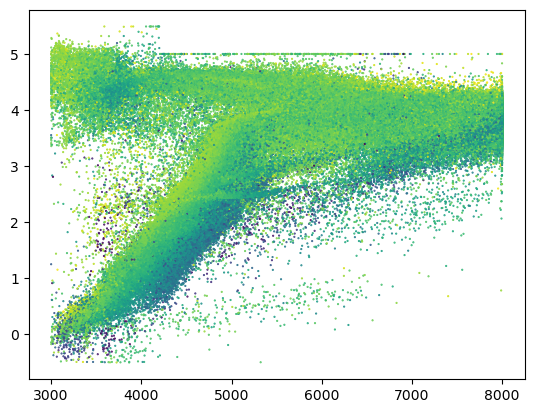

In [31]:
plt.scatter(data["teff"], data["logg"], c=data["fe_h"], s=0.3)

In [32]:
plt.scatter(data["teff"], data["logg"], c=data["age"], s=0.3)

In [33]:
plt.scatter(data["fe_h"], data["alpha"], c=data["age"], s=0.3)

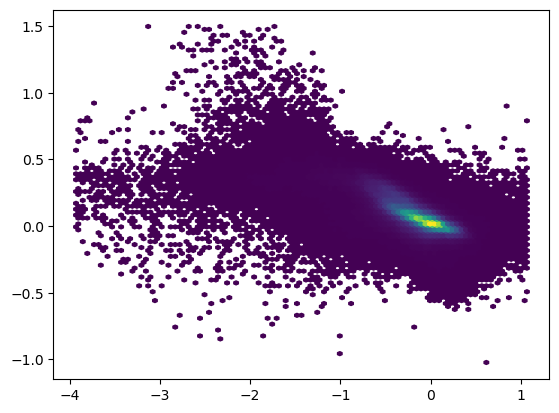

In [34]:
plt.hexbin(data["fe_h"], data["alpha"], mincnt=1, bins=400)

In [57]:
del data
del gaiadf

In [35]:
towrite = Table.from_pandas(data)
towrite.write("ft_galah.fits", overwrite=True, format="fits")

## Combining GALAH and APOGEE

In [4]:
data = Table.read("ft_apogee.fits").to_pandas()
galah = Table.read("ft_galah.fits").to_pandas()

In [5]:
data.describe()

,source_id,teff,e_teff,logg,e_logg,fe_h,e_fe_h,alpha,e_alpha,age,...,ruwe,pmra,pmdec,e_pmra,e_pmdec,pmradec_corr,g_flux_error,bp_flux_error,rp_flux_error,e_parallax
count,5.914990e+05,560381.000000,560381.000000,560381.000000,560381.000000,530202.000000,530202.000000,529904.000000,529904.000000,566168.000000,...,517478.000000,517478.000000,517478.000000,517478.000000,517478.000000,517478.000000,5.174780e+05,5.174780e+05,5.174780e+05,517478.000000
mean,3.024919e+18,4952.934082,25.774536,3.016287,0.034057,-0.231558,0.010797,0.073190,0.028233,5.964135,...,1.496322,-2.217433,-5.012490,0.034914,0.030703,0.003007,2.306389e+02,3.240863e+02,4.609049e+02,0.032829
std,1.817109e+18,1284.999268,69.289841,1.231835,0.045015,0.382288,0.025176,0.103290,0.102697,2.862477,...,2.497080,26.531370,26.468307,0.053053,0.046794,0.222654,9.268409e+03,1.532185e+04,2.492473e+04,0.050378
min,9.281425e+12,3088.049805,2.461126,-0.473392,0.011192,-2.468600,0.003098,-0.713885,0.002055,0.104433,...,0.359607,-1573.040224,-1738.286102,0.005280,0.005924,-0.906645,9.532307e-01,2.235161e+00,3.943031e+00,0.007283
25%,1.451486e+18,4357.337891,8.380351,2.193274,0.023264,-0.401570,0.006705,0.006583,0.006095,3.502972,...,0.979839,-4.875763,-7.213533,0.015039,0.014006,-0.139677,7.315214e+00,1.487355e+01,2.093091e+01,0.014595
50%,3.123882e+18,4771.925781,12.417188,2.814373,0.027622,-0.174450,0.008391,0.043519,0.008274,5.960162,...,1.032526,-1.213709,-2.599892,0.020788,0.018238,0.001313,2.089626e+01,3.178539e+01,4.196284e+01,0.019761
75%,4.271912e+18,5125.395508,22.622633,4.275385,0.034560,0.015832,0.010736,0.109532,0.012814,8.367830,...,1.125972,1.791652,0.526135,0.033886,0.029491,0.151352,6.734319e+01,8.918423e+01,1.057002e+02,0.031176
max,6.917523e+18,19863.927734,11277.411133,5.391378,6.477190,0.968570,4.064234,0.995405,19.249155,19.931976,...,95.250259,2891.518077,1279.193299,0.905524,0.856535,0.946043,5.219406e+06,6.885736e+06,1.319446e+07,1.083091


In [64]:
data.dropna(subset="teff", inplace=True)

In [65]:
galah

,source_id,teff,e_teff,logg,e_logg,fe_h,e_fe_h,alpha,e_alpha,age,e_age,W1,W2,G,BP,RP,bp_1,bp_2,bp_3,bp_4,bp_5,bp_6,bp_7,bp_8,bp_9,bp_10,bp_11,bp_12,bp_13,bp_14,bp_15,bp_16,bp_17,bp_18,bp_19,bp_20,bp_21,bp_22,bp_23,bp_24,bp_25,bp_26,bp_27,bp_28,bp_29,bp_30,bp_31,bp_32,bp_33,bp_34,bp_35,bp_36,bp_37,bp_38,bp_39,bp_40,bp_41,bp_42,bp_43,bp_44,bp_45,bp_46,bp_47,bp_48,bp_49,bp_50,bp_51,bp_52,bp_53,bp_54,bp_55,rp_1,rp_2,rp_3,rp_4,rp_5,rp_6,rp_7,rp_8,rp_9,rp_10,rp_11,rp_12,rp_13,rp_14,rp_15,rp_16,rp_17,rp_18,rp_19,rp_20,rp_21,rp_22,rp_23,rp_24,rp_25,rp_26,rp_27,rp_28,rp_29,rp_30,rp_31,rp_32,rp_33,rp_34,rp_35,rp_36,rp_37,rp_38,rp_39,rp_40,rp_41,rp_42,rp_43,rp_44,rp_45,rp_46,rp_47,rp_48,rp_49,rp_50,rp_51,rp_52,rp_53,rp_54,rp_55,bpe_1,bpe_2,bpe_3,bpe_4,bpe_5,bpe_6,bpe_7,bpe_8,bpe_9,bpe_10,bpe_11,bpe_12,bpe_13,bpe_14,bpe_15,bpe_16,bpe_17,bpe_18,bpe_19,bpe_20,bpe_21,bpe_22,bpe_23,bpe_24,bpe_25,bpe_26,bpe_27,bpe_28,bpe_29,bpe_30,bpe_31,bpe_32,bpe_33,bpe_34,bpe_35,bpe_36,bpe_37,bpe_38,bpe_39,bpe_40,bpe_41,bpe_42,bpe_43,bpe_44,bpe_45,bpe_46,bpe_47,bpe_48,bpe_49,bpe_50,bpe_51,bpe_52,bpe_53,bpe_54,bpe_55,rpe_1,rpe_2,rpe_3,rpe_4,rpe_5,rpe_6,rpe_7,rpe_8,rpe_9,rpe_10,rpe_11,rpe_12,rpe_13,rpe_14,rpe_15,rpe_16,rpe_17,rpe_18,rpe_19,rpe_20,rpe_21,rpe_22,rpe_23,rpe_24,rpe_25,rpe_26,rpe_27,rpe_28,rpe_29,rpe_30,rpe_31,rpe_32,rpe_33,rpe_34,rpe_35,rpe_36,rpe_37,rpe_38,rpe_39,rpe_40,rpe_41,rpe_42,rpe_43,rpe_44,rpe_45,rpe_46,rpe_47,rpe_48,rpe_49,rpe_50,rpe_51,rpe_52,rpe_53,rpe_54,rpe_55,U_SMSS,RA,DEC,E_U_SMSS,V_SMSS,E_V_SMSS,G_SMSS,E_G_SMSS,R_SMSS,E_R_SMSS,I_SMSS,E_I_SMSS,Z_SMSS,E_Z_SMSS,U_SDSS,E_U_SDSS,G_SDSS,E_G_SDSS,R_SDSS,E_R_SDSS,I_SDSS,E_I_SDSS,Z_SDSS,E_Z_SDSS,G_PS1,E_G_PS1,R_PS1,E_R_PS1,I_PS1,E_I_PS1,Z_PS1,E_Z_PS1,Y_PS1,E_Y_PS1,J,E_J,H,E_H,KS,E_KS,PARALLAX,EBV,ruwe,pmra,pmdec,e_pmra,e_pmdec,pmradec_corr,g_flux_error,bp_flux_error,rp_flux_error,e_parallax
0,2745049530295263232,4486.255371,68.002647,4.657445,0.100572,-0.396317,0.055118,0.153393,0.024897,3.215799,1.793265,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,4922452332795612416,4900.511719,72.155556,4.464450,0.102015,-1.032346,0.065797,0.231157,0.042733,0.017005,0.130402,11.589,11.611,13.600912,14.048682,12.978907,464745.307410,-45230.418659,-8403.841114,1867.043248,-930.110770,-3820.129248,-2076.630945,671.645347,-1613.233751,-583.173389,-264.907822,258.211195,-211.765831,98.459865,44.005494,-145.569747,291.141405,-394.309525,-115.753308,-347.300865,-468.475608,571.741199,186.163586,193.846554,199.277828,61.992813,-35.989572,-159.414363,-32.863347,-81.668448,-203.084615,125.751197,46.017938,-55.792780,186.287480,-71.341740,57.742939,-117.825105,69.491574,52.918832,59.180836,-66.085385,-4.752457,-4.004270,-48.570347,-75.751631,114.250120,-52.802457,-40.026735,-53.393364,-42.781828,-51.495352,26.767088,15.216409,-8.699117,540722.785852,-56623.137053,68.751430,43.598122,975.915148,-1046.399523,-626.232724,456.413691,-584.044777,-195.258498,110.841238,55.6

In [66]:
galah.dropna(subset="teff", inplace=True)

In [67]:
data["spec_source"] = "apogee-latentage"
galah["spec_source"] = "galah"
ft_set = pd.concat([galah, data], ignore_index=True)

In [68]:
towrite = Table.from_pandas(ft_set)
towrite.write(
    "/arc/projects/k-pop/catalogues/andrae2023/ftset_spec_ga_0602_realmags.fits",
    overwrite=True,
    format="fits",
)

In [69]:
ft_set.source_id.value_counts()

source_id
5267562747555988480    2
4666490423895957376    2
4654277014375117056    2
5482710372515586944    2
6235884461845547904    2
                      ..
3615271064798156416    1
5851102293223312640    1
5852416995530340480    1
6107596743645773312    1
2772098031734496512    1
Name: count, Length: 1417413, dtype: int64

## Grabbing Li+ 2022 VMPs

In [70]:
vmps = Table.read("li_et_al_x_gaiaids.fits").to_pandas()

In [71]:
vmps["source_id"] = vmps["source_id"].str.decode("utf-8").astype(int)

In [73]:
vmps

,ID,RAdeg,DEdeg,RVel,SNR,Teff,e_Teff,logg,e_logg,FeH,e_FeH,vt,e_vt,logLum,e_logLum,f_logg,Teff-L,logg-L,FeH-L,source_id,has_xp,dist,phot_g_mean_mag,phot_bp_mean_mag,phot_rp_mean_mag
0,b'J0002+0343',0.645994,3.727085,-91.4,23.7,6207,110,4.16,0.05,-3.02,0.24,1.19,0.30,0.307,0.060,0,6361,4.30,-3.36,2740128975242655232,b'True',0.000089,14.924105,15.155141,14.532942
1,b'J0003+1556',0.795383,15.933828,-185.5,32.2,5302,45,2.31,0.08,-2.23,0.11,2.11,0.12,1.883,0.081,0,5289,1.09,-2.62,2772216224937941760,b'True',0.000044,12.084477,12.461968,11.525990
2,b'J0006+1057',1.571676,10.961624,-312.4,20.9,4691,38,1.63,0.14,-3.15,0.14,2.51,0.11,2.350,0.140,1,5012,1.72,-3.15,2765776046033609856,b'True',0.000033,12.593480,13.132258,11.893878
3,b'J0013+2350',3.463742,23.846972,-259.2,41.4,6093,120,3.98,0.04,-2.26,0.09,1.49,0.10,0.455,0.054,0,6238,3.91,-2.20,2848805666604277120,b'True',0.000330,12.159748,12.425416,11.725774
4,b'J0022+4254',5.510848,42.916500,-183.3,23.2,6566,133,3.98,0.06,-2.99,0.25,0.96,0.30,0.585,0.072,0,6250,4.04,-3.36,385205965989661568,b'True',0.000026,14.845626,15.089993,14.433265
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
286,b'J2333+0505',353.356537,5.085501,-136.9,28.2,5035,28,2.05,0.06,-2.43,0.12,2.55,0.09,2.053,0.061,0,5039,1.27,-2.33,2660208219502547584,b'True',0.000031,12.086527,12.563046,11.435070
287,b'J2333+1756',353.352356,17.936150,-309.6,24.9,4736,35,1.74,0.12,-3.22,0.11,2.07,0.10,2.257,0.120,1,4827,1.22,-3.35,2821294236410574080,b'True',0.000027,14.463034,14.995966,13.763576
288,b'J2347+2851',356.998260,28.858528,-241.3,71.3,4864,39,1.88,0.05,-2.36,0.10,1.78,0.04,2.163,0.051,0,4991,1.27,-2.18,2866981452805072640,b'True',0.000054,10.867290,11.351499,10.204917
289,b'J2349+3119',357.373352,31.331707,-91.9,43.6,5064,35,2.50,0.04,-2.01,0.09,1.47,0.03,1.613,0.041,0,5483,2.71,-2.07,2868460399023553664,b'True',0.000095,11.889286,12.374171,11.229742


In [74]:
keep_cols = ["source_id", "Teff", "e_Teff", "logg", "e_logg", "FeH", "e_FeH"]
rename_cols = ["source_id", "teff", "e_teff", "logg", "e_logg", "fe_h", "e_fe_h"]
data = vmps[keep_cols]
data = data.rename(
    columns={"Teff": "teff", "e_Teff": "e_teff", "FeH": "fe_h", "e_FeH": "e_fe_h"}
)

In [76]:
gaiadata = []
with h5py.File("220M_pretrain_data.h5", "r") as f:
    progress_bar = tqdm(f.keys(), total=len(f.keys()))
    for key in progress_bar:
        mask = np.isin(f[key][:]["source_id"], data["source_id"])
        gaiadata.extend([list(tup) for tup in f[key][:][mask]])
    dtypes = f["sslset0_part0"].dtype
    columns = list(dtypes.names)
    f.close()

100%|██████████| 135/135 [26:22<00:00, 11.72s/it]


In [79]:
gaiadf = pd.DataFrame(data=gaiadata, columns=columns)

In [80]:
gaiadf

,source_id,W1,W2,G,BP,RP,bp_1,bp_2,bp_3,bp_4,bp_5,bp_6,bp_7,bp_8,bp_9,bp_10,bp_11,bp_12,bp_13,bp_14,bp_15,bp_16,bp_17,bp_18,bp_19,bp_20,bp_21,bp_22,bp_23,bp_24,bp_25,bp_26,bp_27,bp_28,bp_29,bp_30,bp_31,bp_32,bp_33,bp_34,bp_35,bp_36,bp_37,bp_38,bp_39,bp_40,bp_41,bp_42,bp_43,bp_44,bp_45,bp_46,bp_47,bp_48,bp_49,bp_50,bp_51,bp_52,bp_53,bp_54,bp_55,rp_1,rp_2,rp_3,rp_4,rp_5,rp_6,rp_7,rp_8,rp_9,rp_10,rp_11,rp_12,rp_13,rp_14,rp_15,rp_16,rp_17,rp_18,rp_19,rp_20,rp_21,rp_22,rp_23,rp_24,rp_25,rp_26,rp_27,rp_28,rp_29,rp_30,rp_31,rp_32,rp_33,rp_34,rp_35,rp_36,rp_37,rp_38,rp_39,rp_40,rp_41,rp_42,rp_43,rp_44,rp_45,rp_46,rp_47,rp_48,rp_49,rp_50,rp_51,rp_52,rp_53,rp_54,rp_55,bpe_1,bpe_2,bpe_3,bpe_4,bpe_5,bpe_6,bpe_7,bpe_8,bpe_9,bpe_10,bpe_11,bpe_12,bpe_13,bpe_14,bpe_15,bpe_16,bpe_17,bpe_18,bpe_19,bpe_20,bpe_21,bpe_22,bpe_23,bpe_24,bpe_25,bpe_26,bpe_27,bpe_28,bpe_29,bpe_30,bpe_31,bpe_32,bpe_33,bpe_34,bpe_35,bpe_36,bpe_37,bpe_38,bpe_39,bpe_40,bpe_41,bpe_42,bpe_43,bpe_44,bpe_45,bpe_46,bpe_47,bpe_48,bpe_49,bpe_50,bpe_51,bpe_52,bpe_53,bpe_54,bpe_55,rpe_1,rpe_2,rpe_3,rpe_4,rpe_5,rpe_6,rpe_7,rpe_8,rpe_9,rpe_10,rpe_11,rpe_12,rpe_13,rpe_14,rpe_15,rpe_16,rpe_17,rpe_18,rpe_19,rpe_20,rpe_21,rpe_22,rpe_23,rpe_24,rpe_25,rpe_26,rpe_27,rpe_28,rpe_29,rpe_30,rpe_31,rpe_32,rpe_33,rpe_34,rpe_35,rpe_36,rpe_37,rpe_38,rpe_39,rpe_40,rpe_41,rpe_42,rpe_43,rpe_44,rpe_45,rpe_46,rpe_47,rpe_48,rpe_49,rpe_50,rpe_51,rpe_52,rpe_53,rpe_54,rpe_55,U_SMSS,RA,DEC,E_U_SMSS,V_SMSS,E_V_SMSS,G_SMSS,E_G_SMSS,R_SMSS,E_R_SMSS,I_SMSS,E_I_SMSS,Z_SMSS,E_Z_SMSS,U_SDSS,E_U_SDSS,G_SDSS,E_G_SDSS,R_SDSS,E_R_SDSS,I_SDSS,E_I_SDSS,Z_SDSS,E_Z_SDSS,G_PS1,E_G_PS1,R_PS1,E_R_PS1,I_PS1,E_I_PS1,Z_PS1,E_Z_PS1,Y_PS1,E_Y_PS1,J,E_J,H,E_H,KS,E_KS,PARALLAX,EBV,ruwe,pmra,pmdec,e_pmra,e_pmdec,pmradec_corr,g_flux_error,bp_flux_error,rp_flux_error,e_parallax
0,29184921251610880,9.937,9.962,12.024832,12.486258,11.384337,456146.018324,-43896.642855,-4416.667888,2312.513410,-4564.901446,3969.998780,-975.299693,-377.402652,-508.076258,463.658136,-30.461107,-29.676934,-740.929081,56.944696,450.217351,384.243363,-619.078362,-147.413323,193.938507,-170.524197,-270.807620,-591.042226,535.644776,226.798885,-21.358558,141.586554,56.261564,522.769623,-150.824982,37.337323,56.475416,-241.876743,21.458648,60.304249,-66.850923,-8.542620,148.418774,232.752358,108.009626,146.111629,-87.990117,-186.288291,2.438705,-102.699382,62.572409,-17.781302,16.424541,25.364110,114.304512,-55.141346,35.159973,-9.250748,-5.945325,13.636923,-12.030445,550556.532760,-50495.418083,83.189550,1354.893014,985.377278,-1900.834807,-1756.108204,459.328821,125.202808,1098.645403,-50.616244,1088.014015,-110.226801,-164.147026,-687.827843,199.597464,-42.063479,146.138288,-66.854712,375.366219,-16.971760,106.750957,-99.580904,110.859277,46.372704,-52.180014,-263.949747,-34.600957,-92.030870,-53.754899,109.244644,24.496481,88.670442,140.951242,-29.308339,6.833129,-25.236979,63.513513,119.835202,10.425259,-26.451929,18.678003,-113.615565,88.313414,69.918802,-44.371994,9.456919,-9.745965,-100.146815,19.447695,-6.356516,-36.277340,13.771818,-15.640825,-2.911952,14.076819,11.944532,12.537012,12.374619,12.595191,9.898549,9.377180,11.198088,7.540553,10.918674,11.075139,10.123053,10.734633,6.774144,7.510789,9.939712,9.123025,7.670604,8.381027,5.471805,9.335651,6.831469,7.989402,7.194842,7.293460,6.697082,5.581976,3.479436,5.465684,3.760344,4.380256,4.121758,3.165297,3.811274,2.932318,3.285780,2.897378,3.034362,2.903034,3.052912,2.522981,3.047503,3.446651,2.335226,2.105493,2.561372,2.284993,1.634525,1.378439,1.063502,1.186078,0.703297,0.927227,0.463777,0.202290,6.054551,5.592583,5.422342,6.198806,5.857950,5.957969,5.861550,5.543337,5.388277,6.025361,4.906066,5.782025,3.907582,5.725564,5.409343,5.994341,5.949253,5.211698,5.055019,5.691870,4.191326,5.571660,4.915279,4.922414,5.369080,5.099633,5.121764,4.657136,4.146956,3.973477,4.208075,3.454267,4.071423,3.379279,3.190307,3.031158,2.911652,2.670656,2.414974,2.003900,1.717053,1.977273,2.427728,1.869246,1.973250,2.09977

In [81]:
cols_to_check = [
    "U_SMSS",
    "E_U_SMSS",
    "V_SMSS",
    "E_V_SMSS",
    "G_SMSS",
    "E_G_SMSS",
    "R_SMSS",
    "E_R_SMSS",
    "I_SMSS",
    "E_I_SMSS",
    "Z_SMSS",
    "E_Z_SMSS",
    "U_SDSS",
    "E_U_SDSS",
    "G_SDSS",
    "E_G_SDSS",
    "R_SDSS",
    "E_R_SDSS",
    "I_SDSS",
    "E_I_SDSS",
    "Z_SDSS",
    "E_Z_SDSS",
]

In [82]:
cols_to_check = [
    "U_SMSS",
    "E_U_SMSS",
    "V_SMSS",
    "E_V_SMSS",
    "G_SMSS",
    "E_G_SMSS",
    "R_SMSS",
    "E_R_SMSS",
    "I_SMSS",
    "E_I_SMSS",
    "Z_SMSS",
    "E_Z_SMSS",
    "U_SDSS",
    "E_U_SDSS",
    "G_SDSS",
    "E_G_SDSS",
    "R_SDSS",
    "E_R_SDSS",
    "I_SDSS",
    "E_I_SDSS",
    "Z_SDSS",
    "E_Z_SDSS",
    "G_PS1",
    "E_G_PS1",
    "R_PS1",
    "E_R_PS1",
    "I_PS1",
    "E_I_PS1",
    "Z_PS1",
    "E_Z_PS1",
    "Y_PS1",
    "E_Y_PS1",
]

In [83]:
for col in cols_to_check:
    gaiadf[col] = [np.nan if v in {b"", ""} else float(v) for v in gaiadf[col]]
    gaiadf[col] = gaiadf[col].astype("float64")

In [84]:
gaiadf

,source_id,W1,W2,G,BP,RP,bp_1,bp_2,bp_3,bp_4,bp_5,bp_6,bp_7,bp_8,bp_9,bp_10,bp_11,bp_12,bp_13,bp_14,bp_15,bp_16,bp_17,bp_18,bp_19,bp_20,bp_21,bp_22,bp_23,bp_24,bp_25,bp_26,bp_27,bp_28,bp_29,bp_30,bp_31,bp_32,bp_33,bp_34,bp_35,bp_36,bp_37,bp_38,bp_39,bp_40,bp_41,bp_42,bp_43,bp_44,bp_45,bp_46,bp_47,bp_48,bp_49,bp_50,bp_51,bp_52,bp_53,bp_54,bp_55,rp_1,rp_2,rp_3,rp_4,rp_5,rp_6,rp_7,rp_8,rp_9,rp_10,rp_11,rp_12,rp_13,rp_14,rp_15,rp_16,rp_17,rp_18,rp_19,rp_20,rp_21,rp_22,rp_23,rp_24,rp_25,rp_26,rp_27,rp_28,rp_29,rp_30,rp_31,rp_32,rp_33,rp_34,rp_35,rp_36,rp_37,rp_38,rp_39,rp_40,rp_41,rp_42,rp_43,rp_44,rp_45,rp_46,rp_47,rp_48,rp_49,rp_50,rp_51,rp_52,rp_53,rp_54,rp_55,bpe_1,bpe_2,bpe_3,bpe_4,bpe_5,bpe_6,bpe_7,bpe_8,bpe_9,bpe_10,bpe_11,bpe_12,bpe_13,bpe_14,bpe_15,bpe_16,bpe_17,bpe_18,bpe_19,bpe_20,bpe_21,bpe_22,bpe_23,bpe_24,bpe_25,bpe_26,bpe_27,bpe_28,bpe_29,bpe_30,bpe_31,bpe_32,bpe_33,bpe_34,bpe_35,bpe_36,bpe_37,bpe_38,bpe_39,bpe_40,bpe_41,bpe_42,bpe_43,bpe_44,bpe_45,bpe_46,bpe_47,bpe_48,bpe_49,bpe_50,bpe_51,bpe_52,bpe_53,bpe_54,bpe_55,rpe_1,rpe_2,rpe_3,rpe_4,rpe_5,rpe_6,rpe_7,rpe_8,rpe_9,rpe_10,rpe_11,rpe_12,rpe_13,rpe_14,rpe_15,rpe_16,rpe_17,rpe_18,rpe_19,rpe_20,rpe_21,rpe_22,rpe_23,rpe_24,rpe_25,rpe_26,rpe_27,rpe_28,rpe_29,rpe_30,rpe_31,rpe_32,rpe_33,rpe_34,rpe_35,rpe_36,rpe_37,rpe_38,rpe_39,rpe_40,rpe_41,rpe_42,rpe_43,rpe_44,rpe_45,rpe_46,rpe_47,rpe_48,rpe_49,rpe_50,rpe_51,rpe_52,rpe_53,rpe_54,rpe_55,U_SMSS,RA,DEC,E_U_SMSS,V_SMSS,E_V_SMSS,G_SMSS,E_G_SMSS,R_SMSS,E_R_SMSS,I_SMSS,E_I_SMSS,Z_SMSS,E_Z_SMSS,U_SDSS,E_U_SDSS,G_SDSS,E_G_SDSS,R_SDSS,E_R_SDSS,I_SDSS,E_I_SDSS,Z_SDSS,E_Z_SDSS,G_PS1,E_G_PS1,R_PS1,E_R_PS1,I_PS1,E_I_PS1,Z_PS1,E_Z_PS1,Y_PS1,E_Y_PS1,J,E_J,H,E_H,KS,E_KS,PARALLAX,EBV,ruwe,pmra,pmdec,e_pmra,e_pmdec,pmradec_corr,g_flux_error,bp_flux_error,rp_flux_error,e_parallax
0,29184921251610880,9.937,9.962,12.024832,12.486258,11.384337,456146.018324,-43896.642855,-4416.667888,2312.513410,-4564.901446,3969.998780,-975.299693,-377.402652,-508.076258,463.658136,-30.461107,-29.676934,-740.929081,56.944696,450.217351,384.243363,-619.078362,-147.413323,193.938507,-170.524197,-270.807620,-591.042226,535.644776,226.798885,-21.358558,141.586554,56.261564,522.769623,-150.824982,37.337323,56.475416,-241.876743,21.458648,60.304249,-66.850923,-8.542620,148.418774,232.752358,108.009626,146.111629,-87.990117,-186.288291,2.438705,-102.699382,62.572409,-17.781302,16.424541,25.364110,114.304512,-55.141346,35.159973,-9.250748,-5.945325,13.636923,-12.030445,550556.532760,-50495.418083,83.189550,1354.893014,985.377278,-1900.834807,-1756.108204,459.328821,125.202808,1098.645403,-50.616244,1088.014015,-110.226801,-164.147026,-687.827843,199.597464,-42.063479,146.138288,-66.854712,375.366219,-16.971760,106.750957,-99.580904,110.859277,46.372704,-52.180014,-263.949747,-34.600957,-92.030870,-53.754899,109.244644,24.496481,88.670442,140.951242,-29.308339,6.833129,-25.236979,63.513513,119.835202,10.425259,-26.451929,18.678003,-113.615565,88.313414,69.918802,-44.371994,9.456919,-9.745965,-100.146815,19.447695,-6.356516,-36.277340,13.771818,-15.640825,-2.911952,14.076819,11.944532,12.537012,12.374619,12.595191,9.898549,9.377180,11.198088,7.540553,10.918674,11.075139,10.123053,10.734633,6.774144,7.510789,9.939712,9.123025,7.670604,8.381027,5.471805,9.335651,6.831469,7.989402,7.194842,7.293460,6.697082,5.581976,3.479436,5.465684,3.760344,4.380256,4.121758,3.165297,3.811274,2.932318,3.285780,2.897378,3.034362,2.903034,3.052912,2.522981,3.047503,3.446651,2.335226,2.105493,2.561372,2.284993,1.634525,1.378439,1.063502,1.186078,0.703297,0.927227,0.463777,0.202290,6.054551,5.592583,5.422342,6.198806,5.857950,5.957969,5.861550,5.543337,5.388277,6.025361,4.906066,5.782025,3.907582,5.725564,5.409343,5.994341,5.949253,5.211698,5.055019,5.691870,4.191326,5.571660,4.915279,4.922414,5.369080,5.099633,5.121764,4.657136,4.146956,3.973477,4.208075,3.454267,4.071423,3.379279,3.190307,3.031158,2.911652,2.670656,2.414974,2.003900,1.717053,1.977273,2.427728,1.869246,1.973250,2.09977

In [85]:
data = pd.merge(data, gaiadf, how="left", left_on="source_id", right_on="source_id")

In [86]:
data.dropna(subset="G", inplace=True)
data

,source_id,teff,e_teff,logg,e_logg,fe_h,e_fe_h,W1,W2,G,BP,RP,bp_1,bp_2,bp_3,bp_4,bp_5,bp_6,bp_7,bp_8,bp_9,bp_10,bp_11,bp_12,bp_13,bp_14,bp_15,bp_16,bp_17,bp_18,bp_19,bp_20,bp_21,bp_22,bp_23,bp_24,bp_25,bp_26,bp_27,bp_28,bp_29,bp_30,bp_31,bp_32,bp_33,bp_34,bp_35,bp_36,bp_37,bp_38,bp_39,bp_40,bp_41,bp_42,bp_43,bp_44,bp_45,bp_46,bp_47,bp_48,bp_49,bp_50,bp_51,bp_52,bp_53,bp_54,bp_55,rp_1,rp_2,rp_3,rp_4,rp_5,rp_6,rp_7,rp_8,rp_9,rp_10,rp_11,rp_12,rp_13,rp_14,rp_15,rp_16,rp_17,rp_18,rp_19,rp_20,rp_21,rp_22,rp_23,rp_24,rp_25,rp_26,rp_27,rp_28,rp_29,rp_30,rp_31,rp_32,rp_33,rp_34,rp_35,rp_36,rp_37,rp_38,rp_39,rp_40,rp_41,rp_42,rp_43,rp_44,rp_45,rp_46,rp_47,rp_48,rp_49,rp_50,rp_51,rp_52,rp_53,rp_54,rp_55,bpe_1,bpe_2,bpe_3,bpe_4,bpe_5,bpe_6,bpe_7,bpe_8,bpe_9,bpe_10,bpe_11,bpe_12,bpe_13,bpe_14,bpe_15,bpe_16,bpe_17,bpe_18,bpe_19,bpe_20,bpe_21,bpe_22,bpe_23,bpe_24,bpe_25,bpe_26,bpe_27,bpe_28,bpe_29,bpe_30,bpe_31,bpe_32,bpe_33,bpe_34,bpe_35,bpe_36,bpe_37,bpe_38,bpe_39,bpe_40,bpe_41,bpe_42,bpe_43,bpe_44,bpe_45,bpe_46,bpe_47,bpe_48,bpe_49,bpe_50,bpe_51,bpe_52,bpe_53,bpe_54,bpe_55,rpe_1,rpe_2,rpe_3,rpe_4,rpe_5,rpe_6,rpe_7,rpe_8,rpe_9,rpe_10,rpe_11,rpe_12,rpe_13,rpe_14,rpe_15,rpe_16,rpe_17,rpe_18,rpe_19,rpe_20,rpe_21,rpe_22,rpe_23,rpe_24,rpe_25,rpe_26,rpe_27,rpe_28,rpe_29,rpe_30,rpe_31,rpe_32,rpe_33,rpe_34,rpe_35,rpe_36,rpe_37,rpe_38,rpe_39,rpe_40,rpe_41,rpe_42,rpe_43,rpe_44,rpe_45,rpe_46,rpe_47,rpe_48,rpe_49,rpe_50,rpe_51,rpe_52,rpe_53,rpe_54,rpe_55,U_SMSS,RA,DEC,E_U_SMSS,V_SMSS,E_V_SMSS,G_SMSS,E_G_SMSS,R_SMSS,E_R_SMSS,I_SMSS,E_I_SMSS,Z_SMSS,E_Z_SMSS,U_SDSS,E_U_SDSS,G_SDSS,E_G_SDSS,R_SDSS,E_R_SDSS,I_SDSS,E_I_SDSS,Z_SDSS,E_Z_SDSS,G_PS1,E_G_PS1,R_PS1,E_R_PS1,I_PS1,E_I_PS1,Z_PS1,E_Z_PS1,Y_PS1,E_Y_PS1,J,E_J,H,E_H,KS,E_KS,PARALLAX,EBV,ruwe,pmra,pmdec,e_pmra,e_pmdec,pmradec_corr,g_flux_error,bp_flux_error,rp_flux_error,e_parallax
0,2740128975242655232,6207,110,4.16,0.05,-3.02,0.24,13.746,13.780,14.924105,15.155141,14.532942,510135.367131,-127830.365010,17747.721893,-4280.028882,-293.551458,5167.932435,1829.295683,-691.847165,-1258.711979,768.316283,-578.636540,-342.587826,-413.402613,418.899415,118.208780,381.911154,-1089.131192,118.760459,498.949764,109.395333,546.487902,-1137.915531,272.462812,-191.887941,-556.489161,-24.429855,448.842780,526.853688,451.308792,144.410182,846.996415,44.382795,-253.220940,-329.383471,-440.646209,-76.599287,204.134900,-128.121138,370.129321,169.496116,-106.673370,-181.659089,364.869958,82.954025,59.164994,-86.169263,-229.737993,-173.058461,234.093797,19.368116,167.717921,32.799165,21.744453,40.543426,-2.823964,433977.067578,-75014.625571,-5082.624273,-2304.539643,-600.670661,436.648934,-350.204432,-363.356909,-27.666770,432.475755,-69.658862,543.152562,-213.135159,-65.618999,-1.949970,563.119833,91.839627,-105.885017,157.927383,1.147994,-50.126303,84.618547,152.744546,327.936887,569.403130,-881.046179,45.948699,226.973305,101.907186,-378.065284,-433.268636,184.207444,-101.708364,146.010466,-25.754120,-25.687606,-274.521709,-220.103312,210.791204,-72.268797,89.338079,-43.856753,-86.864552,5.615320,-68.019484,29.111665,110.799626,8.538192,-88.527484,-191.715626,111.606775,-25.003533,8.647763,35.275699,17.548883,1.964025,1.730229,1.732393,1.811184,1.858967,1.589170,1.354568,2.267762,1.384915,1.547076,1.700647,1.541983,1.639448,1.030180,1.206598,1.583500,1.531854,1.208823,1.442860,1.025516,1.601823,1.262071,1.376243,1.275655,1.298211,1.188370,1.018823,0.725655,1.024374,0.665391,0.832040,0.924170,0.670953,0.801295,0.612127,0.639947,0.608388,0.638000,0.563903,0.687163,0.479411,0.619108,0.756173,0.413390,0.453400,0.596662,0.565550,0.408410,0.361588,0.252737,0.246451,0.165252,0.176540,0.116378,0.051530,0.812665,0.763307,0.742040,0.834627,0.763978,0.806533,0.791586,0.757064,0.725612,0.816376,0.667746,0.780714,0.542200,0.768436,0.767690,0.827870,0.751397,0.705179,0.732702,0.809068,0.614727,0.788679,0.709246,0.702247,0.784588,0.766142,0.743554,0.683223,0.615146,0.614165,0.637088,0.521174,0.629625,0.521020,0.495801,0.474978,0.4570

In [87]:
data.dtypes

source_id          int64
teff               int16
e_teff             int16
logg             float64
e_logg           float64
                  ...   
pmradec_corr     float32
g_flux_error     float32
bp_flux_error    float32
rp_flux_error    float32
e_parallax       float32
Length: 284, dtype: object

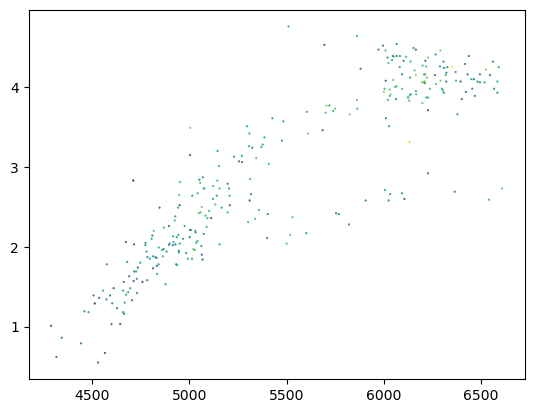

In [89]:
plt.scatter(data["teff"], data["logg"], c=data["fe_h"], s=0.3)

In [90]:
ft_set

,source_id,teff,e_teff,logg,e_logg,fe_h,e_fe_h,alpha,e_alpha,age,e_age,W1,W2,G,BP,RP,bp_1,bp_2,bp_3,bp_4,bp_5,bp_6,bp_7,bp_8,bp_9,bp_10,bp_11,bp_12,bp_13,bp_14,bp_15,bp_16,bp_17,bp_18,bp_19,bp_20,bp_21,bp_22,bp_23,bp_24,bp_25,bp_26,bp_27,bp_28,bp_29,bp_30,bp_31,bp_32,bp_33,bp_34,bp_35,bp_36,bp_37,bp_38,bp_39,bp_40,bp_41,bp_42,bp_43,bp_44,bp_45,bp_46,bp_47,bp_48,bp_49,bp_50,bp_51,bp_52,bp_53,bp_54,bp_55,rp_1,rp_2,rp_3,rp_4,rp_5,rp_6,rp_7,rp_8,rp_9,rp_10,rp_11,rp_12,rp_13,rp_14,rp_15,rp_16,rp_17,rp_18,rp_19,rp_20,rp_21,rp_22,rp_23,rp_24,rp_25,rp_26,rp_27,rp_28,rp_29,rp_30,rp_31,rp_32,rp_33,rp_34,rp_35,rp_36,rp_37,rp_38,rp_39,rp_40,rp_41,rp_42,rp_43,rp_44,rp_45,rp_46,rp_47,rp_48,rp_49,rp_50,rp_51,rp_52,rp_53,rp_54,rp_55,bpe_1,bpe_2,bpe_3,bpe_4,bpe_5,bpe_6,bpe_7,bpe_8,bpe_9,bpe_10,bpe_11,bpe_12,bpe_13,bpe_14,bpe_15,bpe_16,bpe_17,bpe_18,bpe_19,bpe_20,bpe_21,bpe_22,bpe_23,bpe_24,bpe_25,bpe_26,bpe_27,bpe_28,bpe_29,bpe_30,bpe_31,bpe_32,bpe_33,bpe_34,bpe_35,bpe_36,bpe_37,bpe_38,bpe_39,bpe_40,bpe_41,bpe_42,bpe_43,bpe_44,bpe_45,bpe_46,bpe_47,bpe_48,bpe_49,bpe_50,bpe_51,bpe_52,bpe_53,bpe_54,bpe_55,rpe_1,rpe_2,rpe_3,rpe_4,rpe_5,rpe_6,rpe_7,rpe_8,rpe_9,rpe_10,rpe_11,rpe_12,rpe_13,rpe_14,rpe_15,rpe_16,rpe_17,rpe_18,rpe_19,rpe_20,rpe_21,rpe_22,rpe_23,rpe_24,rpe_25,rpe_26,rpe_27,rpe_28,rpe_29,rpe_30,rpe_31,rpe_32,rpe_33,rpe_34,rpe_35,rpe_36,rpe_37,rpe_38,rpe_39,rpe_40,rpe_41,rpe_42,rpe_43,rpe_44,rpe_45,rpe_46,rpe_47,rpe_48,rpe_49,rpe_50,rpe_51,rpe_52,rpe_53,rpe_54,rpe_55,U_SMSS,RA,DEC,E_U_SMSS,V_SMSS,E_V_SMSS,G_SMSS,E_G_SMSS,R_SMSS,E_R_SMSS,I_SMSS,E_I_SMSS,Z_SMSS,E_Z_SMSS,U_SDSS,E_U_SDSS,G_SDSS,E_G_SDSS,R_SDSS,E_R_SDSS,I_SDSS,E_I_SDSS,Z_SDSS,E_Z_SDSS,G_PS1,E_G_PS1,R_PS1,E_R_PS1,I_PS1,E_I_PS1,Z_PS1,E_Z_PS1,Y_PS1,E_Y_PS1,J,E_J,H,E_H,KS,E_KS,PARALLAX,EBV,ruwe,pmra,pmdec,e_pmra,e_pmdec,pmradec_corr,g_flux_error,bp_flux_error,rp_flux_error,e_parallax,spec_source
0,2745049530295263232,4486.255371,68.002647,4.657445,0.100572,-0.396317,0.055118,0.153393,0.024897,3.215799,1.793265,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,galah
1,4922452332795612416,4900.511719,72.155556,4.464450,0.102015,-1.032346,0.065797,0.231157,0.042733,0.017005,0.130402,11.589,11.611,13.600912,14.048682,12.978907,464745.307410,-45230.418659,-8403.841114,1867.043248,-930.110770,-3820.129248,-2076.630945,671.645347,-1613.233751,-583.173389,-264.907822,258.211195,-211.765831,98.459865,44.005494,-145.569747,291.141405,-394.309525,-115.753308,-347.300865,-468.475608,571.741199,186.163586,193.846554,199.277828,61.992813,-35.989572,-159.414363,-32.863347,-81.668448,-203.084615,125.751197,46.017938,-55.792780,186.287480,-71.341740,57.742939,-117.825105,69.491574,52.918832,59.180836,-66.085385,-4.752457,-4.004270,-48.570347,-75.751631,114.250120,-52.802457,-40.026735,-53.393364,-42.781828,-51.495352,26.767088,15.216409,-8.699117,540722.785852,-56623.137053,68.751430,43.598122,975.915148,-1046.399523,-626.232724,456.413691,-584.044777,-195.2584

In [91]:
data["spec_source"] = "li_et_al_vmps"
ft_set2 = pd.concat([ft_set, data], ignore_index=True)

In [92]:
ft_set2

,source_id,teff,e_teff,logg,e_logg,fe_h,e_fe_h,alpha,e_alpha,age,e_age,W1,W2,G,BP,RP,bp_1,bp_2,bp_3,bp_4,bp_5,bp_6,bp_7,bp_8,bp_9,bp_10,bp_11,bp_12,bp_13,bp_14,bp_15,bp_16,bp_17,bp_18,bp_19,bp_20,bp_21,bp_22,bp_23,bp_24,bp_25,bp_26,bp_27,bp_28,bp_29,bp_30,bp_31,bp_32,bp_33,bp_34,bp_35,bp_36,bp_37,bp_38,bp_39,bp_40,bp_41,bp_42,bp_43,bp_44,bp_45,bp_46,bp_47,bp_48,bp_49,bp_50,bp_51,bp_52,bp_53,bp_54,bp_55,rp_1,rp_2,rp_3,rp_4,rp_5,rp_6,rp_7,rp_8,rp_9,rp_10,rp_11,rp_12,rp_13,rp_14,rp_15,rp_16,rp_17,rp_18,rp_19,rp_20,rp_21,rp_22,rp_23,rp_24,rp_25,rp_26,rp_27,rp_28,rp_29,rp_30,rp_31,rp_32,rp_33,rp_34,rp_35,rp_36,rp_37,rp_38,rp_39,rp_40,rp_41,rp_42,rp_43,rp_44,rp_45,rp_46,rp_47,rp_48,rp_49,rp_50,rp_51,rp_52,rp_53,rp_54,rp_55,bpe_1,bpe_2,bpe_3,bpe_4,bpe_5,bpe_6,bpe_7,bpe_8,bpe_9,bpe_10,bpe_11,bpe_12,bpe_13,bpe_14,bpe_15,bpe_16,bpe_17,bpe_18,bpe_19,bpe_20,bpe_21,bpe_22,bpe_23,bpe_24,bpe_25,bpe_26,bpe_27,bpe_28,bpe_29,bpe_30,bpe_31,bpe_32,bpe_33,bpe_34,bpe_35,bpe_36,bpe_37,bpe_38,bpe_39,bpe_40,bpe_41,bpe_42,bpe_43,bpe_44,bpe_45,bpe_46,bpe_47,bpe_48,bpe_49,bpe_50,bpe_51,bpe_52,bpe_53,bpe_54,bpe_55,rpe_1,rpe_2,rpe_3,rpe_4,rpe_5,rpe_6,rpe_7,rpe_8,rpe_9,rpe_10,rpe_11,rpe_12,rpe_13,rpe_14,rpe_15,rpe_16,rpe_17,rpe_18,rpe_19,rpe_20,rpe_21,rpe_22,rpe_23,rpe_24,rpe_25,rpe_26,rpe_27,rpe_28,rpe_29,rpe_30,rpe_31,rpe_32,rpe_33,rpe_34,rpe_35,rpe_36,rpe_37,rpe_38,rpe_39,rpe_40,rpe_41,rpe_42,rpe_43,rpe_44,rpe_45,rpe_46,rpe_47,rpe_48,rpe_49,rpe_50,rpe_51,rpe_52,rpe_53,rpe_54,rpe_55,U_SMSS,RA,DEC,E_U_SMSS,V_SMSS,E_V_SMSS,G_SMSS,E_G_SMSS,R_SMSS,E_R_SMSS,I_SMSS,E_I_SMSS,Z_SMSS,E_Z_SMSS,U_SDSS,E_U_SDSS,G_SDSS,E_G_SDSS,R_SDSS,E_R_SDSS,I_SDSS,E_I_SDSS,Z_SDSS,E_Z_SDSS,G_PS1,E_G_PS1,R_PS1,E_R_PS1,I_PS1,E_I_PS1,Z_PS1,E_Z_PS1,Y_PS1,E_Y_PS1,J,E_J,H,E_H,KS,E_KS,PARALLAX,EBV,ruwe,pmra,pmdec,e_pmra,e_pmdec,pmradec_corr,g_flux_error,bp_flux_error,rp_flux_error,e_parallax,spec_source
0,2745049530295263232,4486.255371,68.002647,4.657445,0.100572,-0.396317,0.055118,0.153393,0.024897,3.215799,1.793265,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,galah
1,4922452332795612416,4900.511719,72.155556,4.464450,0.102015,-1.032346,0.065797,0.231157,0.042733,0.017005,0.130402,11.589,11.611,13.600912,14.048682,12.978907,464745.307410,-45230.418659,-8403.841114,1867.043248,-930.110770,-3820.129248,-2076.630945,671.645347,-1613.233751,-583.173389,-264.907822,258.211195,-211.765831,98.459865,44.005494,-145.569747,291.141405,-394.309525,-115.753308,-347.300865,-468.475608,571.741199,186.163586,193.846554,199.277828,61.992813,-35.989572,-159.414363,-32.863347,-81.668448,-203.084615,125.751197,46.017938,-55.792780,186.287480,-71.341740,57.742939,-117.825105,69.491574,52.918832,59.180836,-66.085385,-4.752457,-4.004270,-48.570347,-75.751631,114.250120,-52.802457,-40.026735,-53.393364,-42.781828,-51.495352,26.767088,15.216409,-8.699117,540722.785852,-56623.137053,68.751430,43.598122,975.915148,-1046.399523,-626.232724,456.413691,-584.044777,-195.2584

In [93]:
towrite = Table.from_pandas(ft_set2)
towrite.write(
    "/arc/projects/k-pop/catalogues/andrae2023/ftset_spec_ga_0602_realmags.fits",
    overwrite=True,
    format="fits",
)

In [94]:
ft_set2.source_id.value_counts()

source_id
2558459589561967232    3
677825553901841024     2
5266300714372302336    2
3579083796370254592    2
2680527610995890560    2
                      ..
5789959344894958208    1
3612903610105230848    1
6064863326579995136    1
6287725369932977152    1
2746403063468526976    1
Name: count, Length: 1417678, dtype: int64

In [95]:
plt.scatter(ft_set2["teff"], ft_set2["logg"], c=ft_set2["fe_h"], s=0.3)

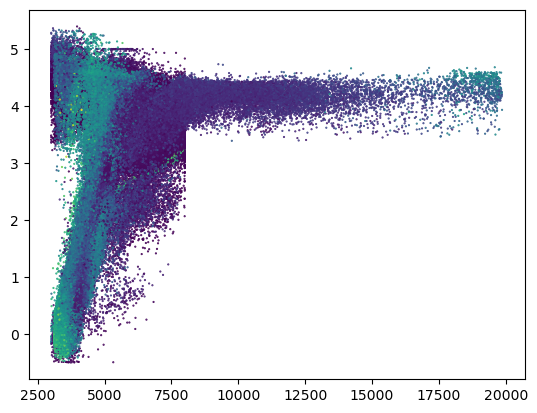

In [96]:
plt.scatter(ft_set2["teff"], ft_set2["logg"], c=ft_set2["age"], s=0.3)

In [97]:
plt.scatter(ft_set2["fe_h"], ft_set2["alpha"], c=ft_set2["age"], s=0.3)

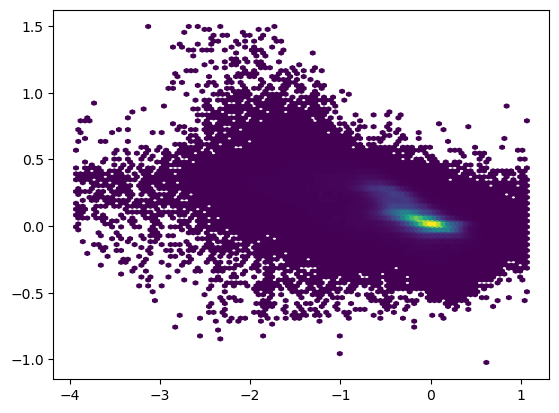

In [98]:
plt.hexbin(ft_set2["fe_h"], ft_set2["alpha"], mincnt=1, bins=400)

## Ensuring there are no NaNs

In [2]:
ft_set = Table.read(
    "/arc/projects/k-pop/catalogues/andrae2023/ftset_spec_ga_0602_realmags.fits"
).to_pandas()

In [3]:
ft_set = ft_set.dropna(subset=["G"])

In [5]:
ft_set

,source_id,teff,e_teff,logg,e_logg,fe_h,e_fe_h,alpha,e_alpha,age,...,pmra,pmdec,e_pmra,e_pmdec,pmradec_corr,g_flux_error,bp_flux_error,rp_flux_error,e_parallax,spec_source
1,4922452332795612416,4900.511719,72.155556,4.464450,0.102015,-1.032346,0.065797,0.231157,0.042733,0.017005,...,48.081076,-26.275559,0.018121,0.019242,-0.240860,8.874296,21.170980,25.110329,0.019836,b'galah'
2,4919409709243747968,5543.346191,73.427536,4.175371,0.102718,-0.654349,0.064612,0.292858,0.041623,13.842698,...,-25.856214,-19.845870,0.026805,0.034231,-0.361083,25.730244,21.331488,30.726351,0.028713,b'galah'
3,4685221429109310080,5529.029297,68.877304,4.521021,0.104782,0.135527,0.056800,-0.009852,0.028337,3.414711,...,36.991526,-3.560709,0.010837,0.011559,0.007231,59.822346,103.126923,101.638260,0.010136,b'galah'
4,4683766775225601664,4977.451172,74.996758,3.172151,0.113069,-0.612790,0.065126,0.292203,0.056503,10.581185,...,19.906693,-6.288807,0.017682,0.016394,-0.011029,22.013437,43.652412,42.689857,0.014520,b'galah'
5,4976477592542752384,5694.408691,68.380760,4.450530,0.094544,0.107221,0.055985,-0.002314,0.025627,4.739285,...,-13.233209,-17.704181,0.016248,0.021259,-0.320080,71.948509,73.069214,57.047688,0.025190,b'galah'
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1467347,2660208219502547584,5035.000000,28.000000,2.050000,0.060000,-2.430000,0.120000,NaN,NaN,NaN,...,7.871509,-5.787074,0.019304,0.012343,-0.044844,72.566360,108.573586,78.593178,0.015708,b'li_et_al_vmps'
1467348,2821294236410574080,4736.000000,35.000000,1.740000,0.120000,-3.220000,0.110000,NaN,NaN,NaN,...,3.246224,0.196585,0.025464,0.016026,-0.019815,6.843498,17.676014,15.031563,0.020790,b'li_et_al_vmps'
1467349,2866981452805072640,4864.000000,39.000000,1.880000,0.050000,-2.360000,0.100000,NaN,NaN,NaN,...,12.530756,-8.622131,0.019843,0.013190,-0.094139,119.320923,121.389618,158.698059,0.017005,b'li_et_al_vmps'
1467350,2868460399023553664,5064.000000,35.000000,2.500000,0.040000,-2.010000,0.090000,NaN,NaN,NaN,...,11.361697,-17.698827,0.014992,0.010419,-0.067467,71.869263,103.345322,104.781082,0.014907,b'li_et_al_vmps'


In [6]:
towrite = Table.from_pandas(ft_set)
towrite.write(
    "/arc/projects/k-pop/catalogues/andrae2023/ftset_spec_ga_0602_realmags.fits",
    overwrite=True,
    format="fits",
)